In [185]:
import pandas as pd
import numpy as np
import re

import seaborn as sns
import matplotlib.pyplot as plt

In [186]:
df = pd.read_excel('../data/bd_IA.xlsx')

LIMPIEZA

In [187]:
df.head()

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
0,1,2019-01-08 00:00:00,REFINANCAIACION,BUSINESS,2700000,48.0,COLPENSIONES,1961.0,DESEMBOLSADO,2022-02-21 00:00:00,61.0
1,2,2019-05-29 00:00:00,LIBRE INVERSION,COOPIDESARROLLO,6000000,36.0,COLPENSIONES,1939.0,DESEMBOLSADO,2019-06-11 00:00:00,80.0
2,3,2019-05-30 00:00:00,LIBRE INVERSION,COOPIDESARROLLO,5000000,48.0,CAGEN,1944.0,DESEMBOLSADO,2019-06-25 00:00:00,75.0
3,4,2019-05-30 00:00:00,COMPRA,CREDIVALORES,24000000,120.0,CASUR,1972.0,DESEMBOLSADO,2019-06-28 00:00:00,47.0
4,5,2019-06-04 00:00:00,COMPRA,EXCELCREDIT,7560000,120.0,CAGEN,1980.0,DESEMBOLSADO,2019-07-05 00:00:00,39.0


In [188]:
df.shape

(1657, 11)

In [189]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1657 entries, 0 to 1656
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_CLIENTE           1657 non-null   int64  
 1   FECHA                1655 non-null   object 
 2   TIPO DE CREDITO      1654 non-null   object 
 3   COOPERATIVA          1649 non-null   str    
 4   MONTO                1613 non-null   object 
 5   PLAZO                1645 non-null   float64
 6   PAGADURIA            1656 non-null   str    
 7   ANIO_NACIMIENTO      1560 non-null   float64
 8   ESTADO               1656 non-null   str    
 9   FECHA DE DESEMBOLSO  1479 non-null   object 
 10  EDAD_AL_PRESTAMO     1224 non-null   float64
dtypes: float64(3), int64(1), object(4), str(3)
memory usage: 142.5+ KB


In [190]:
df.describe()

,ID_CLIENTE,PLAZO,ANIO_NACIMIENTO,EDAD_AL_PRESTAMO
count,1657.000000,1645.000000,1560.000000,1224.000000
mean,344.255884,84.289862,1957.550641,60.668301
std,220.940684,40.193031,14.162577,20.263460
min,1.000000,0.000000,1927.000000,-46.000000
25%,167.000000,48.000000,1948.000000,55.000000
50%,312.000000,72.000000,1956.000000,65.000000
75%,519.000000,120.000000,1964.000000,73.000000
max,809.000000,180.000000,2024.000000,94.000000


In [191]:
df.isnull().sum()

ID_CLIENTE               0
FECHA                    2
TIPO DE CREDITO          3
COOPERATIVA              8
MONTO                   44
PLAZO                   12
PAGADURIA                1
ANIO_NACIMIENTO         97
ESTADO                   1
FECHA DE DESEMBOLSO    178
EDAD_AL_PRESTAMO       433
dtype: int64

Fechas Limpieza (Fecha y Fecha de Desembolso)

In [192]:
df_clean = df.copy()

In [193]:
df_clean['FECHA'] = pd.to_datetime(df_clean['FECHA'])

In [194]:
df_clean[df_clean['FECHA'].isna()]

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
1634,139,NaT,REFINANCIACION,NaN,NaN,NaN,COLPENSIONES,1957.0,ESTUDIO,NaN,NaN
1635,649,NaT,LIBRE,NaN,NaN,NaN,NaN,1948.0,ESTUDIO,NaN,NaN


In [195]:
df_clean['FECHA'].dt.year.unique()

array([2019., 2020., 2021., 2022., 2023., 2024., 2025., 2026.,   nan])

In [196]:
df_clean['FECHA'].dt.year.value_counts().sort_index()

FECHA
2019.0    135
2020.0    199
2021.0    307
2022.0    262
2023.0    224
2024.0    211
2025.0    210
2026.0    107
Name: count, dtype: int64

In [197]:
df_clean['FECHA DE DESEMBOLSO'] = df_clean['FECHA DE DESEMBOLSO'].astype(str)
valores_unicos = df_clean['FECHA DE DESEMBOLSO'].unique()
print(valores_unicos[:20])

<StringArray>
['2022-02-21 00:00:00', '2019-06-11 00:00:00', '2019-06-25 00:00:00',
 '2019-06-28 00:00:00', '2019-07-05 00:00:00', '2019-07-12 00:00:00',
 '2019-06-10 00:00:00',                   '0', '2019-06-22 00:00:00',
            '00:00:00', '2019-07-25 00:00:00', '2019-07-17 00:00:00',
 '2019-08-02 00:00:00', '2019-07-19 00:00:00', '2019-07-23 00:00:00',
 '2019-07-31 00:00:00', '2019-08-14 00:00:00', '2019-07-26 00:00:00',
 '2019-09-10 00:00:00', '2019-08-05 00:00:00']
Length: 20, dtype: str


In [198]:
df_clean['FECHA DE DESEMBOLSO'] = df_clean['FECHA DE DESEMBOLSO'].replace(
    ['0', '00:00:00', 'nan', 'NaT'],
    np.nan
)

In [199]:
df_clean['FECHA DE DESEMBOLSO'].isnull().sum()

np.int64(461)

In [200]:
df_clean['FECHA DE DESEMBOLSO'] = pd.to_datetime(df_clean['FECHA DE DESEMBOLSO'],errors='coerce')

In [201]:
df_clean['FECHA DE DESEMBOLSO'].dt.strftime('%Y-%m-%d')

0       2022-02-21
1       2019-06-11
2       2019-06-25
3       2019-06-28
4       2019-07-05
           ...    
1652           NaN
1653           NaN
1654           NaN
1655           NaN
1656           NaN
Name: FECHA DE DESEMBOLSO, Length: 1657, dtype: str

In [202]:
df_clean.dtypes

ID_CLIENTE                      int64
FECHA                  datetime64[us]
TIPO DE CREDITO                object
COOPERATIVA                       str
MONTO                          object
PLAZO                         float64
PAGADURIA                         str
ANIO_NACIMIENTO               float64
ESTADO                            str
FECHA DE DESEMBOLSO    datetime64[us]
EDAD_AL_PRESTAMO              float64
dtype: object

Variable Estado Limpieza

In [203]:
# Normalizar texto
df_clean['ESTADO'] = (
    df_clean['ESTADO'].astype(str).str.upper().str.strip())

In [204]:
# Mapping directo a clases finales
mapping_estado_final = {
    # DESEMBOLSADO
    'DEEMBOLSADO': 'DESEMBOLSADO',
    'DERSEMBOLSADO': 'DESEMBOLSADO',
    'DESEMBIOLSADO': 'DESEMBOLSADO',
    'DESEMBOLASADO': 'DESEMBOLSADO',
    'DESEMBOLSADO': 'DESEMBOLSADO',
    'DESEMBOLSADO+Q1181P1181:T11P1181:S1181': 'DESEMBOLSADO',
    'DESEMBOLSAO': 'DESEMBOLSADO',
    'DESEMBOLSASDO': 'DESEMBOLSADO',
    'DESEMBOLSO': 'DESEMBOLSADO',
    'DESEMBOLSSADO': 'DESEMBOLSADO',
    'DESEMBOSALDO': 'DESEMBOLSADO',
    'DESERMBOLSADO': 'DESEMBOLSADO',
    'DESMBOLSADO': 'DESEMBOLSADO',
    'DESMBOSLADO': 'DESEMBOLSADO',

    # NO DESEMBOLSADO
    'NEGADA': 'NO_DESEMBOLSADO',
    'NEGADIO': 'NO_DESEMBOLSADO',
    'NEGADO': 'NO_DESEMBOLSADO',
    'DESISTE': 'NO_DESEMBOLSADO',

    # EN PROCESO
    'ESTUDIO': 'EN_PROCESO',
    'APROBADO': 'EN_PROCESO'
}

In [205]:
# Aplicar mapping
df_clean['ESTADO'] = df_clean['ESTADO'].replace(mapping_estado_final)

In [206]:
df_clean['ESTADO'].value_counts()

ESTADO
DESEMBOLSADO       1281
NO_DESEMBOLSADO     330
EN_PROCESO           45
Name: count, dtype: int64

Relación entre Estado del Crédito y Presencia de Fecha de Desembolso

In [207]:
pd.crosstab(df_clean['ESTADO'], df_clean['FECHA DE DESEMBOLSO'].isnull())

FECHA DE DESEMBOLSO,False,True
ESTADO,,
DESEMBOLSADO,1187,94
EN_PROCESO,2,43
NO_DESEMBOLSADO,4,326


In [208]:
df_clean['ESTADO'].unique()

<StringArray>
['DESEMBOLSADO', 'NO_DESEMBOLSADO', 'EN_PROCESO', nan]
Length: 4, dtype: str

In [209]:
# Fila que tiene NAN en variables importantes
df_clean[df_clean['ESTADO'] == 'NAN']

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO


In [210]:
df_clean = df_clean.drop(index=1395)

In [211]:
# Préstamos NO desembolsados pero que tienen fecha de desembolso
df_clean[
    (df_clean['ESTADO'] == 'NO_DESEMBOLSADO') &
    (df_clean['FECHA DE DESEMBOLSO'].notnull())
]

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
540,353,2021-09-13,LIBRE INVERSION,BUSINESS,0,48.0,COLPENSIONES,1946.0,NO_DESEMBOLSADO,1900-01-01,-46.0
856,219,2022-08-19,COMPRA,BAYPORT,-7000000,144.0,COLPENSIONES,1943.0,NO_DESEMBOLSADO,2022-02-10,79.0
878,321,2022-09-28,COMPRA,TU RESPALDO,27504415,180.0,COLPENSIONES,1944.0,NO_DESEMBOLSADO,2022-09-27,78.0
1247,24,2024-05-07,LIBRE,TEKA,0,60.0,SOLDADO PROFESIONAL,1992.0,NO_DESEMBOLSADO,2024-05-27,32.0


In [212]:
df_clean.loc[[540, 856, 878, 1247], 'FECHA DE DESEMBOLSO'] = pd.NaT

In [213]:
df_clean.loc[[540, 856, 878, 1247],
             ['ESTADO', 'FECHA DE DESEMBOLSO']]

,ESTADO,FECHA DE DESEMBOLSO
540,NO_DESEMBOLSADO,NaT
856,NO_DESEMBOLSADO,NaT
878,NO_DESEMBOLSADO,NaT
1247,NO_DESEMBOLSADO,NaT


In [214]:
pd.crosstab(df_clean['ESTADO'], df_clean['FECHA DE DESEMBOLSO'].isnull())

FECHA DE DESEMBOLSO,False,True
ESTADO,,
DESEMBOLSADO,1187,94
EN_PROCESO,2,43
NO_DESEMBOLSADO,0,330


Edad al Préstamo Y Año de nacimiento Limpieza

In [215]:
df_clean['ANIO_NACIMIENTO'] = df_clean['ANIO_NACIMIENTO'].astype('Int64')
df_clean['EDAD_AL_PRESTAMO'] = df_clean['EDAD_AL_PRESTAMO'].astype('Int64')

In [216]:
# Identificar edades negativas
df_clean[df_clean['EDAD_AL_PRESTAMO'] <= 0]

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
28,24,2019-07-18,LIBRE INVERSION,COPFINANCIAR,3000000,36.0,SOLDADO PROFESIONAL,1992,DESEMBOLSADO,NaT,-22
159,132,2020-01-22,COMPRA,VIVECREDITO,17400888,84.0,CREMIL,1972,DESEMBOLSADO,NaT,-2
217,172,2020-03-03,LIBRE INVERSION,FUNDACION,2000000,24.0,EMPLEADO,1991,DESEMBOLSADO,NaT,-21
230,184,2020-03-13,LIBRE INVERSION,FUNDACION,5000000,24.0,ACTIVO,1972,DESEMBOLSADO,NaT,-2
236,187,2020-05-14,LIBRE INVERSION,MISSION,14000000,108.0,CASUR,1971,NO_DESEMBOLSADO,NaT,-1
257,198,2020-06-30,REFINANCIACION,PRONALCREDIT,13800000,72.0,SEGUROS BOLIVAR,1970,DESEMBOLSADO,NaT,0
269,204,2020-07-23,COMPRA,VIVECREDITO,16755756,144.0,FOPEP,2020,DESEMBOLSADO,2020-09-14,0
271,4,2020-07-30,REFINANCIACION,CREDIVALORES,24636388,132.0,CASUR,1972,DESEMBOLSADO,NaT,-2
273,67,2020-08-18,REFINANCIACION,MISSION,0,60.0,COLPENSIONES,2012,DESEMBOLSADO,NaT,-42
297,215,2020-09-23,LIBRE INVERSION,VIVECREDITO,2134561,132.0,COLPENSIONES,1970,DESEMBOLSADO,NaT,0


In [217]:
df_clean['ANIO_NACIMIENTO'] = pd.to_numeric(df_clean['ANIO_NACIMIENTO'], errors='coerce')

In [218]:
#Recalcular la edad al préstamo (año(FECHA) - ANIO_NACIMIENTO)
df_clean['EDAD_AL_PRESTAMO'] = (
    df_clean['FECHA'].dt.year - df_clean['ANIO_NACIMIENTO']
)

In [219]:
(df_clean['EDAD_AL_PRESTAMO'] <= 0).sum()

np.int64(5)

In [220]:
indices = [28, 159, 217, 230, 236, 271, 273, 298, 396, 422, 424, 524, 540, 578, 589, 620, 709, 742]

df_clean.loc[indices]

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
28,24,2019-07-18,LIBRE INVERSION,COPFINANCIAR,3000000,36.0,SOLDADO PROFESIONAL,1992,DESEMBOLSADO,NaT,27.0
159,132,2020-01-22,COMPRA,VIVECREDITO,17400888,84.0,CREMIL,1972,DESEMBOLSADO,NaT,48.0
217,172,2020-03-03,LIBRE INVERSION,FUNDACION,2000000,24.0,EMPLEADO,1991,DESEMBOLSADO,NaT,29.0
230,184,2020-03-13,LIBRE INVERSION,FUNDACION,5000000,24.0,ACTIVO,1972,DESEMBOLSADO,NaT,48.0
236,187,2020-05-14,LIBRE INVERSION,MISSION,14000000,108.0,CASUR,1971,NO_DESEMBOLSADO,NaT,49.0
271,4,2020-07-30,REFINANCIACION,CREDIVALORES,24636388,132.0,CASUR,1972,DESEMBOLSADO,NaT,48.0
273,67,2020-08-18,REFINANCIACION,MISSION,0,60.0,COLPENSIONES,2012,DESEMBOLSADO,NaT,8.0
298,216,2020-09-23,LIBRE INVERSION,COPFINANCIAR,7500000,72.0,BBVA SEGUROS,1977,NO_DESEMBOLSADO,NaT,43.0
396,270,2021-02-18,LIBRE INVERSION,MISSION,0,60.0,SEM CALI,1971,NO_DESEMBOLSADO,NaT,50.0
422,98,2021-03-16,LIBRE INVERSION,BUSINESS,0,60.0,COLPENSIONES,1989,NO_DESEMBOLSADO,NaT,32.0


In [221]:
# Entre los registrados hay niños que heredan la pensión cuando los padres mueren. Los tutores podían hacer préstamos sobre la pensión del menor de edad
df_clean[df_clean['ANIO_NACIMIENTO'] > 2005]

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
72,67,2019-09-03,LIBRE INVERSION,MISSION,5000000,60.0,COLPENSIONES,2012,DESEMBOLSADO,2019-09-20,7.0
269,204,2020-07-23,COMPRA,VIVECREDITO,16755756,144.0,FOPEP,2020,DESEMBOLSADO,2020-09-14,0.0
273,67,2020-08-18,REFINANCIACION,MISSION,0,60.0,COLPENSIONES,2012,DESEMBOLSADO,NaT,8.0
387,67,2021-02-15,REFINANCIACION,MISSION,876000,60.0,COLPENSIONES,2012,DESEMBOLSADO,2021-02-26,9.0
505,334,2021-08-09,COMPRA,BAYPORT,0,144.0,MINDEFENSA,2021,NO_DESEMBOLSADO,NaT,0.0
561,364,2021-10-04,LIBRE INVERSION,MISSION,7000000,72.0,COLPENSIONES,2011,DESEMBOLSADO,2021-10-20,10.0
858,509,2022-08-22,LIBRE,BUSINESS,6500000,36.0,FOPEP,2007,DESEMBOLSADO,2022-09-16,15.0
974,67,2023-02-20,LIBRE,BUSINESS,1800000,48.0,COLPENSIONES,2012,DESEMBOLSADO,2023-03-29,11.0
982,543,2023-03-02,LIBRE,BUSINESS,0,72.0,COLPENSIONES,2014,NO_DESEMBOLSADO,NaT,9.0
1019,564,2023-04-13,LIBRE,BUSINESS,5800000,36.0,COLPENSIONES,2009,DESEMBOLSADO,2023-04-28,14.0


In [222]:
# Años de nacimiento inválidos
df_clean[df_clean['ANIO_NACIMIENTO'] >= 2020]

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
269,204,2020-07-23,COMPRA,VIVECREDITO,16755756,144.0,FOPEP,2020,DESEMBOLSADO,2020-09-14,0.0
505,334,2021-08-09,COMPRA,BAYPORT,0,144.0,MINDEFENSA,2021,NO_DESEMBOLSADO,NaT,0.0
1168,606,2024-01-26,LIBRE,BUSINESS,2100000,36.0,COLFONDOS,2024,DESEMBOLSADO,2024-03-18,0.0
1169,505,2024-01-26,LIBRE,BUSINESS,3400000,72.0,SEGUROS BOLIVAR,2024,DESEMBOLSADO,2024-02-26,0.0
1304,232,2024-09-30,REFINANCIACAION,BUSINESS,2500000,72.0,COLPENSIONES,2024,DESEMBOLSADO,2024-10-19,0.0


In [223]:
nacimiento_invalido = df_clean['ANIO_NACIMIENTO'] >= 2020

df_clean.loc[nacimiento_invalido, 'ANIO_NACIMIENTO'] = np.nan
df_clean.loc[nacimiento_invalido, 'EDAD_AL_PRESTAMO'] = np.nan

In [224]:
df_clean.loc[nacimiento_invalido, ['ANIO_NACIMIENTO', 'EDAD_AL_PRESTAMO']]

,ANIO_NACIMIENTO,EDAD_AL_PRESTAMO
269,<NA>,<NA>
505,<NA>,<NA>
1168,<NA>,<NA>
1169,<NA>,<NA>
1304,<NA>,<NA>


In [225]:
df_clean['EDAD_AL_PRESTAMO'].unique()

<FloatingArray>
[58.0, 80.0, 75.0, 47.0, 39.0, <NA>, 41.0, 61.0, 74.0, 67.0, 81.0, 22.0, 87.0,
 51.0, 28.0, 76.0, 60.0, 77.0, 65.0, 27.0, 82.0, 71.0, 56.0, 70.0, 53.0, 37.0,
 88.0, 57.0, 59.0, 72.0, 86.0, 49.0, 66.0, 69.0, 68.0, 50.0, 62.0, 73.0, 92.0,
 52.0,  7.0, 63.0, 40.0, 85.0, 64.0, 55.0, 91.0, 46.0, 79.0, 45.0, 54.0, 30.0,
 78.0, 17.0, 48.0, 84.0, 26.0, 36.0, 29.0, 83.0, 90.0,  8.0, 43.0, 89.0, 38.0,
 31.0,  9.0, 44.0, 34.0, 32.0, 33.0, 35.0, 24.0, 10.0, 42.0, 25.0, 15.0, 11.0,
 94.0, 14.0, 93.0]
Length: 81, dtype: Float64

In [226]:
df_clean['EDAD_AL_PRESTAMO'].value_counts().sort_index()

EDAD_AL_PRESTAMO
7.0     1
8.0     1
9.0     2
10.0    1
11.0    1
       ..
90.0    8
91.0    7
92.0    4
93.0    1
94.0    3
Name: count, Length: 80, dtype: Int64

In [227]:
#Préstamos a menores de edad
df_clean[df_clean['EDAD_AL_PRESTAMO'] < 18]

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
72,67,2019-09-03,LIBRE INVERSION,MISSION,5000000,60.0,COLPENSIONES,2012,DESEMBOLSADO,2019-09-20,7.0
154,131,2020-01-20,COMPRA,MISSION,4000000,12.0,COLPENSIONES,2003,NO_DESEMBOLSADO,NaT,17.0
273,67,2020-08-18,REFINANCIACION,MISSION,0,60.0,COLPENSIONES,2012,DESEMBOLSADO,NaT,8.0
387,67,2021-02-15,REFINANCIACION,MISSION,876000,60.0,COLPENSIONES,2012,DESEMBOLSADO,2021-02-26,9.0
561,364,2021-10-04,LIBRE INVERSION,MISSION,7000000,72.0,COLPENSIONES,2011,DESEMBOLSADO,2021-10-20,10.0
858,509,2022-08-22,LIBRE,BUSINESS,6500000,36.0,FOPEP,2007,DESEMBOLSADO,2022-09-16,15.0
974,67,2023-02-20,LIBRE,BUSINESS,1800000,48.0,COLPENSIONES,2012,DESEMBOLSADO,2023-03-29,11.0
982,543,2023-03-02,LIBRE,BUSINESS,0,72.0,COLPENSIONES,2014,NO_DESEMBOLSADO,NaT,9.0
1019,564,2023-04-13,LIBRE,BUSINESS,5800000,36.0,COLPENSIONES,2009,DESEMBOLSADO,2023-04-28,14.0


Monto Limpieza

In [228]:
df_clean['MONTO'] = pd.to_numeric(df_clean['MONTO'], errors='coerce')

In [229]:
df_clean['MONTO'].dtype

dtype('float64')

In [230]:
df_clean['MONTO'].describe()

count    1.607000e+03
mean     7.205494e+06
std      1.145665e+07
min     -4.000000e+07
25%      1.700000e+06
50%      4.000000e+06
75%      9.149326e+06
max      1.447118e+08
Name: MONTO, dtype: float64

In [231]:
# Montos negativos
df_clean[df_clean['MONTO'] < 0]

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
7,8,2019-06-10,COMPRA,BAYPORT,-1.238000e+07,120.00000,COLPENSIONES,1944,NO_DESEMBOLSADO,NaT,75.0
9,10,2019-06-20,LIBRE INVERSION,EXCELCREDIT,-4.400000e+06,120.00000,COLPENSIONES,1945,NO_DESEMBOLSADO,NaT,74.0
10,11,2019-06-20,LIBRE INVERSION,BAYPORT,-2.220345e+06,120.00000,COLPENSIONES,1952,NO_DESEMBOLSADO,NaT,67.0
22,19,2019-07-16,LIBRE INVERSION,MISSION,-5.700000e+06,96.00000,COLPENSIONES,1943,NO_DESEMBOLSADO,NaT,76.0
25,22,2019-07-18,COMPRA,MISSION,-6.500000e+06,96.00000,COLPENSIONES,1939,NO_DESEMBOLSADO,NaT,80.0
35,31,2019-07-30,LIBRE INVERSION,MISSION,-1.000000e+06,24.00000,POLICIA,1982,NO_DESEMBOLSADO,NaT,37.0
38,34,2019-08-01,LIBRE INVERSION,MISSION,-4.000000e+07,108.00000,CASUR,1958,NO_DESEMBOLSADO,NaT,61.0
41,37,2019-08-09,COMPRA,COOPIDESARROLLO,-2.500000e+06,72.00000,CASUR,1945,NO_DESEMBOLSADO,NaT,74.0
44,40,2019-08-12,COMPRA,MISSION,-1.500000e+07,96.00000,FIDUPREVISORA,1944,NO_DESEMBOLSADO,NaT,75.0
45,41,2019-08-12,COMPRA,CREDIVALORES,-1.681390e+07,144.00000,COLPENSIONES,1947,NO_DESEMBOLSADO,NaT,72.0


In [232]:
# Convertir montos negativos a positivos
df_clean['MONTO'] = df_clean['MONTO'].abs()

In [233]:
(df_clean['MONTO'] < 0).sum()

np.int64(0)

In [234]:
df_clean[df_clean['MONTO'] == 0]

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
40,36,2019-08-08,REFINANCIACION,COPFINANCIAR,0.0,72.0,PROTECCION,1959,DESEMBOLSADO,2019-08-23,60.0
124,109,2019-11-28,COMPRA,GIROS Y FINANZAS,0.0,120.0,COLPENSIONES,<NA>,NO_DESEMBOLSADO,NaT,<NA>
137,120,2020-01-07,LIBRE INVERSION,MISSION,0.0,60.0,SOLDADO PROFESIONAL,<NA>,NO_DESEMBOLSADO,NaT,<NA>
160,133,2020-01-23,COMPRA,VIVECREDITO,0.0,84.0,SEC. BUENAVENTURA,1965,NO_DESEMBOLSADO,NaT,55.0
167,138,2020-02-03,LIBRE INVERSION,CREDIVALORES,0.0,120.0,COLPENSIONES,1950,NO_DESEMBOLSADO,NaT,70.0
...,...,...,...,...,...,...,...,...,...,...,...
1477,729,2025-09-02,LIBRE,BUSINESS,0.0,84.0,FIDUPREVISORA,<NA>,NO_DESEMBOLSADO,NaT,<NA>
1486,291,2025-09-11,COMPRA,KREDIT,0.0,144.0,COLPENSIONES,<NA>,NO_DESEMBOLSADO,NaT,<NA>
1487,547,2025-09-15,LIBRE,EXCELCREDIT,0.0,84.0,SEGUROS ALFA,1964,NO_DESEMBOLSADO,NaT,61.0
1488,732,2025-09-16,LIBRE,BUSINESS,0.0,84.0,FOPEP,<NA>,NO_DESEMBOLSADO,NaT,<NA>


In [235]:
# Montos de créditos desembolsados en 0 (4)
df_clean[(df_clean['MONTO'] == 0) & (df_clean['ESTADO'] == 'DESEMBOLSADO')]

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO
40,36,2019-08-08,REFINANCIACION,COPFINANCIAR,0.0,72.0,PROTECCION,1959,DESEMBOLSADO,2019-08-23,60.0
273,67,2020-08-18,REFINANCIACION,MISSION,0.0,60.0,COLPENSIONES,2012,DESEMBOLSADO,NaT,8.0
631,202,2021-12-10,COMPRA,KREDIT,0.0,144.0,COLPENSIONES,1952,DESEMBOLSADO,NaT,69.0
751,350,2022-03-04,COMPRA,EXCELCREDIT,0.0,0.0,COLPENSIONES,1952,DESEMBOLSADO,2022-03-17,70.0


In [236]:
# Montos NO desembolsados en 0
((df_clean['MONTO'] == 0) & (df_clean['ESTADO'] == 'NO_DESEMBOLSADO')).sum()

np.int64(155)

In [237]:
# Convertir montos en 0 a Nan
df_clean.loc[df_clean['MONTO'] == 0, 'MONTO'] = np.nan

In [238]:
(df_clean['MONTO'] == 0).sum()

np.int64(0)

In [239]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1656 entries, 0 to 1656
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_CLIENTE           1656 non-null   int64         
 1   FECHA                1654 non-null   datetime64[us]
 2   TIPO DE CREDITO      1653 non-null   object        
 3   COOPERATIVA          1648 non-null   str           
 4   MONTO                1444 non-null   float64       
 5   PLAZO                1644 non-null   float64       
 6   PAGADURIA            1655 non-null   str           
 7   ANIO_NACIMIENTO      1554 non-null   Int64         
 8   ESTADO               1656 non-null   str           
 9   FECHA DE DESEMBOLSO  1189 non-null   datetime64[us]
 10  EDAD_AL_PRESTAMO     1552 non-null   Float64       
dtypes: Float64(1), Int64(1), datetime64[us](2), float64(2), int64(1), object(1), str(3)
memory usage: 223.0+ KB


In [240]:
# Diagnóstico previo tipo de credito
print("Valores únicos originales:", df_clean['TIPO DE CREDITO'].nunique())
print("Nulos:", df_clean['TIPO DE CREDITO'].isnull().sum())
print(df_clean['TIPO DE CREDITO'].value_counts())

Valores únicos originales: 37
Nulos: 3
TIPO DE CREDITO
LIBRE                      571
LIBRE INVERSION            438
COMPRA                     298
REFINANCIACION             176
LIBRE INVERSION             51
LIBRE                       44
COMPRA                      10
LIBRE - DIGITAL              7
REFINANCIACION               7
COMPRA DE CARTERA            6
COMPRA - DIGITAL             5
REFINANCAIACION              4
PLAN PRIMA                   4
SANEAMIENTO                  3
REFINANCIACIÓN               3
REFI                         2
LIBRRE                       2
LIRRE                        2
REFINANCIACIÓN               2
ACTIVO                       1
REFINANCICION                1
LIBE INVERSION               1
REFINANCION                  1
REFNANCIACION                1
0                            1
LIBERE                       1
DIGICREDIT  SANEAMIENTO      1
DIGICREDIT COMPRA            1
REFINANCIACAION              1
26902000                     1
REFINANACIACION

In [241]:
def normalizar_tipo_credito(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().upper()
    v = re.sub(r'\s+', ' ', v)

    if re.search(r'COMPRA.*(CART|CARTE)', v):       return 'COMPRA DE CARTERA'
    if 'COMPRA' in v and 'REFI' in v:               return 'COMPRA DE CARTERA'  # → COMPRA DE CARTERA
    if 'COMPRA' in v and 'DIGIT' in v:              return 'COMPRA DE CARTERA'  # → COMPRA DE CARTERA
    if re.search(r'DIG.*COMPRA', v):                return 'COMPRA DE CARTERA'
    if re.search(r'DIG.*SANE', v):                  return 'REFINANCIACIÓN'
    if 'COMPRA' in v:                               return 'COMPRA DE CARTERA'  # → COMPRA DE CARTERA
    if re.search(r'RE[FN]I', v):                    return 'REFINANCIACIÓN'
    if 'SANEAMIENTO' in v:                          return 'REFINANCIACIÓN'     # → REFINANCIACIÓN
    if 'PLAN PRIMA' in v:                           return 'OTROS'
    if 'LIBRE' in v and ('INV' in v or 'IVE' in v): return 'LIBRE INVERSIÓN'
    if 'LIBRE' in v and 'DIGIT' in v:               return 'LIBRE INVERSIÓN'   # → LIBRE INVERSIÓN
    if re.search(r'LI[BR]{2,}E|LI[RB]{2}E|LIBE?RE?', v): return 'LIBRE INVERSIÓN'
    if 'LIBRE' in v:                                return 'LIBRE INVERSIÓN'   # → LIBRE INVERSIÓN
    if 'ACTIVO' in v:                               return 'OTROS'

    return np.nan

df_clean['TIPO DE CREDITO'] = df_clean['TIPO DE CREDITO'].apply(normalizar_tipo_credito)
print("Valores únicos después de limpieza:", df_clean['TIPO DE CREDITO'].nunique())
print("Nulos resultantes:", df_clean['TIPO DE CREDITO'].isnull().sum())
print(df_clean['TIPO DE CREDITO'].value_counts())

Valores únicos después de limpieza: 4
Nulos resultantes: 8
TIPO DE CREDITO
LIBRE INVERSIÓN      1116
COMPRA DE CARTERA     321
REFINANCIACIÓN        206
OTROS                   5
Name: count, dtype: int64


In [242]:

print("Valores únicos originales:", df_clean['COOPERATIVA'].nunique())
print("Nulos:", df_clean['COOPERATIVA'].isnull().sum())
print(df_clean['COOPERATIVA'].value_counts())

Valores únicos originales: 44
Nulos: 8
COOPERATIVA
BUSINESS              438
PRONALCREDIT          269
EXCELCREDIT           159
COOPIDESARROLLO       121
MISSION               105
COPFINANCIAR           98
BAYPORT                89
VIVECREDITO            79
COOPSANDER             39
KREDIT                 38
BAN100                 37
LINK                   28
CREDIVALORES           27
TU RESPALDO            14
FUNDACION              13
KALA                   12
AVISTA                  9
CONFINANCIA             7
GIROS Y FINANZAS        6
COOPIDESARROLLO         6
COOPFINANCIAR           6
EXCEL CREDIT            6
ACTIVAR                 6
TEKA                    4
FIANTI                  3
AYF                     3
FIANTI                  3
KREDIFACIL              3
MISSION                 2
EXCELCRDIT              2
CREDITO2                2
EXCELCREDIT             2
SUDAMERIS               1
CREDIFINANCIERA         1
KREDIT                  1
BAYPORT CLICK           1
COOBOLARQUI  

In [243]:
mapa_cooperativa = {
    # EXCELCREDIT (variantes)
    'EXCEL CREDIT':       'EXCELCREDIT',
    'EXCELCRDIT':         'EXCELCREDIT',
    'EXCECREDIT':         'EXCELCREDIT',
    # COPFINANCIAR (variantes)
    'COOPFINANCIAR':      'COPFINANCIAR',
    'COFINANCIA':         'COPFINANCIAR',
    'CONFINANCIA':        'COPFINANCIAR',
    # BAYPORT (variantes)
    'BAYPORT CLICK':      'BAYPORT',
    'BAYPORT FISICO':     'BAYPORT',
    # KREDIT (variantes)
    'KREDIFACIL':         'KREDIT',
    # COBOLARQUI (variantes)
    'COOBOLARQUI':        'COBOLARQUI',
    # ACTIVOS Y FINANZAS
    'AYF':                'ACTIVOS Y FINANZAS',
    # COMCREDIT
    'CREDITO2':           'COMCREDIT',
    # CREDIFINANCIERA (corregido typo)
    'CREDIFINANCIERA':    'CREDIFINANCIERA',
}

def normalizar_cooperativa(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().upper()
    v = re.sub(r'\s+', ' ', v)
    return mapa_cooperativa.get(v, v)

df_clean['COOPERATIVA'] = df_clean['COOPERATIVA'].apply(normalizar_cooperativa)
print("Valores únicos después de limpieza:", df_clean['COOPERATIVA'].nunique())
print("Nulos:", df_clean['COOPERATIVA'].isnull().sum())
print(df_clean['COOPERATIVA'].value_counts())

Valores únicos después de limpieza: 27
Nulos: 8
COOPERATIVA
BUSINESS              438
PRONALCREDIT          269
EXCELCREDIT           170
COOPIDESARROLLO       127
COPFINANCIAR          112
MISSION               107
BAYPORT                91
VIVECREDITO            79
KREDIT                 42
COOPSANDER             39
BAN100                 37
LINK                   28
CREDIVALORES           27
TU RESPALDO            14
FUNDACION              13
KALA                   12
AVISTA                  9
GIROS Y FINANZAS        6
FIANTI                  6
ACTIVAR                 6
ACTIVOS Y FINANZAS      4
TEKA                    4
COMCREDIT               3
COBOLARQUI              2
SUDAMERIS               1
CREDIFINANCIERA         1
COMUNIDAD               1
Name: count, dtype: int64


In [244]:
print("Valores únicos originales:", df_clean['PAGADURIA'].nunique())
print("Nulos:", df_clean['PAGADURIA'].isnull().sum())


Valores únicos originales: 81
Nulos: 1


In [245]:
def normalizar_pagaduria(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().upper()
    v = re.sub(r'\s+', ' ', v)

    # COLPENSIONES (variantes: COLPESIONES, COLEPNSIONES, etc.)
    if re.search(r'COL[PE]ENS|COLPENS|COLPESION|COLEPNS|COPENS|COLEPENS', v): return 'COLPENSIONES'
    # CASUR
    if 'CASUR' in v:            return 'CASUR'
    # FOPEP
    if 'FOPEP' in v:            return 'FOPEP'
    # FIDUPREVISORA
    if 'FIDUPREV' in v:         return 'FIDUPREVISORA'
    # PORVENIR
    if 'PORVENIR' in v:         return 'PORVENIR'
    # COLFONDOS
    if 'COLFOND' in v:          return 'COLFONDOS'
    # PROTECCION
    if 'PROTECC' in v:          return 'PROTECCION'
    # FERROCARRILES
    if re.search(r'FERROC|FERCAL|FER VAL', v): return 'FERROCARRILES'
    # SEGUROS ALFA
    if re.search(r'SEG(URO)?S? (DE VIDA )?ALFA|SEGUIROS ALFA', v): return 'SEGUROS ALFA'
    # SEGUROS BOLIVAR
    if re.search(r'SEG(URO)?S? BOLIV|SEG\. BOLIV', v): return 'SEGUROS BOLIVAR'
    # MAPFRE
    if 'MAPFRE' in v:           return 'MAPFRE'
    # CREMIL
    if 'CREMIL' in v:           return 'CREMIL'
    # TEGEN
    if 'TEGEN' in v:            return 'TEGEN'
    # ASULADO
    if 'ASULADO' in v:          return 'ASULADO'
    # POLICIA NACIONAL
    if re.search(r'POLICI', v): return 'POLICIA NACIONAL'
    # POSITIVA
    if 'POSITIVA' in v:         return 'POSITIVA'
    # EJERCITO
    if re.search(r'EJER|ARMADA', v): return 'EJERCITO'
    # ALLIANZ SEGUROS
    if re.search(r'ALL?I[AÁ]N[ZS]', v): return 'ALLIANZ SEGUROS'
    # MINDEFENSA (incluye MINISTERIO DE DEFENSA)
    if re.search(r'MINDEF[EE]?[NS]|MINISTERIO DE DEFENSA', v): return 'MINDEFENSA'
    # SOLDADO PROFESIONAL
    if 'SOLDADO' in v:          return 'SOLDADO PROFESIONAL'
    # CREMIL ya cubierto arriba
    # SEM
    if re.search(r'SEM (CALI|HUILA)|PENSIONADO SEM|^SEM$', v): return 'SEM'
    # GOBERNACION (incluye PEN GOV CAUCA)
    if re.search(r'PEN.*GOV|GOB(ERNACION)?.*(VALLE|CAUCA)|GOBERNACION', v): return 'GOBERNACION'
    # MUNICIPIO/ALCALDIA (incluye PENSIONADO DEL MUNICIPIO)
    if re.search(r'MUN(ICIPIO)?.*(CALI|MEDELLIN)|ALCALDIA|ALC (BUEN|CAL)|PENSIONADO DEL MUNIC', v): return 'MUNICIPIO/ALCALDIA'
    # CAGEN
    if 'CAGEN' in v:            return 'CAGEN'
    # AXA COLPATRIA
    if re.search(r'AXA|COLPATRIA', v): return 'AXA COLPATRIA'
    # BBVA SEGUROS
    if 'BBVA' in v:             return 'BBVA SEGUROS'
    # SEGUROS LA EQUIDAD
    if re.search(r'(SEG(URO)?S?|SEGUI?ROS?) (LA )?EQUIDAD', v): return 'SEGUROS LA EQUIDAD'
    # SURA
    if re.search(r'SURA|SURAMER', v): return 'SURA'
    # GLOBAL SEGUROS
    if 'GLOBAL' in v:           return 'GLOBAL SEGUROS'
    # FOMAG
    if 'FOMAG' in v:            return 'FOMAG'
    # SEC. EDUCACION (incluye SEC. BUENAVENTURA)
    if re.search(r'SEC(RETAR)?.*EDUC|SEC ED|SEC.*BUENAVENTURA', v): return 'SEC. EDUCACION'
    # ECOPETROL
    if 'ECOPETROL' in v:        return 'ECOPETROL'
    # FISCALIA
    if 'FISCAL' in v:           return 'FISCALIA'
    # INCAUCA
    if 'INCAUCA' in v:          return 'INCAUCA'
    # CAFETO SOFWARE → empresa privada
    if 'CAFETO' in v:           return 'EMPLEADO'
    # EMPLEADO
    if 'EMPLEADO' in v:         return 'EMPLEADO'
    # ACTIVO
    if 'ACTIVO' in v:           return 'ACTIVO'

    return v

df_clean['PAGADURIA'] = df_clean['PAGADURIA'].apply(normalizar_pagaduria)
print("Valores únicos después de limpieza:", df_clean['PAGADURIA'].nunique())
print("Nulos:", df_clean['PAGADURIA'].isnull().sum())
print(df_clean['PAGADURIA'].value_counts())

Valores únicos después de limpieza: 36
Nulos: 1
PAGADURIA
COLPENSIONES           973
CASUR                   81
SEGUROS ALFA            72
FOPEP                   62
PORVENIR                61
COLFONDOS               52
FIDUPREVISORA           40
SEGUROS BOLIVAR         37
PROTECCION              29
FERROCARRILES           28
MAPFRE                  24
CREMIL                  19
SOLDADO PROFESIONAL     17
TEGEN                   15
POLICIA NACIONAL        14
EJERCITO                13
ASULADO                 12
POSITIVA                11
SURA                    10
GOBERNACION             10
ALLIANZ SEGUROS         10
MINDEFENSA               9
MUNICIPIO/ALCALDIA       8
EMPLEADO                 6
SEM                      6
CAGEN                    5
SEC. EDUCACION           5
GLOBAL SEGUROS           5
BBVA SEGUROS             4
ACTIVO                   4
SEGUROS LA EQUIDAD       4
AXA COLPATRIA            4
FOMAG                    2
ECOPETROL                1
INCAUCA                 

In [246]:
print("Tipo de dato:", df_clean['ID_CLIENTE'].dtype)
print("Nulos:", df_clean['ID_CLIENTE'].isnull().sum())
print("Total registros:", len(df_clean))
print("IDs únicos:", df_clean['ID_CLIENTE'].nunique())
print("IDs duplicados:", df_clean['ID_CLIENTE'].duplicated().sum())
print("Min:", df_clean['ID_CLIENTE'].min(), "| Max:", df_clean['ID_CLIENTE'].max())


Tipo de dato: int64
Nulos: 0
Total registros: 1656
IDs únicos: 809
IDs duplicados: 847
Min: 1 | Max: 809


In [247]:
# ID_CLIENTE NO es un identificador único por registro:
# el mismo cliente puede tener múltiples créditos (1 nulo, 848 duplicados sobre 1658 filas).
# → Convertir a int, no eliminar duplicados (son créditos distintos del mismo cliente).

df_clean['ID_CLIENTE'] = df_clean['ID_CLIENTE'].astype('Int64')  # soporta NaN
print("Nulos en ID_CLIENTE:", df_clean['ID_CLIENTE'].isnull().sum())
print("Tipo final:", df_clean['ID_CLIENTE'].dtype)
# El nulo de ID_CLIENTE se deja como NaN; se revisará si impacta el modelo.

Nulos en ID_CLIENTE: 0
Tipo final: Int64


In [248]:
# Limpieza para las fechas de desembolso negativas o mayores a 30 días
# Calcular diferencia cruda
df_clean["DIAS_HASTA_DESEMBOLSO"] = (
    df_clean["FECHA DE DESEMBOLSO"] - df_clean["FECHA"]
).dt.days

# Diagnóstico antes de limpiar
print("ANTES de limpiar:")
print(df_clean["DIAS_HASTA_DESEMBOLSO"].describe().round(2))
print(f"\nValores negativos:  {(df_clean['DIAS_HASTA_DESEMBOLSO'] < 0).sum()}")
print(f"Valores > 30 días:  {(df_clean['DIAS_HASTA_DESEMBOLSO'] > 30).sum()}")

# Dejar nulos los valores fuera del rango válido [0, 30]
mask_invalido = (
    df_clean["DIAS_HASTA_DESEMBOLSO"] < 0
) | (
    df_clean["DIAS_HASTA_DESEMBOLSO"] > 30
)
df_clean.loc[mask_invalido, "DIAS_HASTA_DESEMBOLSO"] = np.nan

print(f"\nRegistros anulados: {mask_invalido.sum()}")
print("\nDESPUÉS de limpiar:")
print(df_clean["DIAS_HASTA_DESEMBOLSO"].describe().round(2))

ANTES de limpiar:
count    1189.00
mean        9.05
std       121.27
min     -3626.00
25%         6.00
50%        12.00
75%        20.00
max      1140.00
Name: DIAS_HASTA_DESEMBOLSO, dtype: float64

Valores negativos:  21
Valores > 30 días:  135

Registros anulados: 156

DESPUÉS de limpiar:
count    1033.00
mean       11.39
std         7.74
min         0.00
25%         5.00
50%        11.00
75%        16.00
max        30.00
Name: DIAS_HASTA_DESEMBOLSO, dtype: float64


EDA

In [249]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1656 entries, 0 to 1656
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID_CLIENTE             1656 non-null   Int64         
 1   FECHA                  1654 non-null   datetime64[us]
 2   TIPO DE CREDITO        1648 non-null   str           
 3   COOPERATIVA            1648 non-null   str           
 4   MONTO                  1444 non-null   float64       
 5   PLAZO                  1644 non-null   float64       
 6   PAGADURIA              1655 non-null   str           
 7   ANIO_NACIMIENTO        1554 non-null   Int64         
 8   ESTADO                 1656 non-null   str           
 9   FECHA DE DESEMBOLSO    1189 non-null   datetime64[us]
 10  EDAD_AL_PRESTAMO       1552 non-null   Float64       
 11  DIAS_HASTA_DESEMBOLSO  1033 non-null   float64       
dtypes: Float64(1), Int64(2), datetime64[us](2), float64(3), str(4)
memory usage: 2

In [250]:
nulos = df_clean.isnull().sum()
pct_nulos = (nulos / len(df_clean) * 100).round(2)
resumen_nulos = pd.DataFrame({"Nulos": nulos, "% Nulos": pct_nulos})
resumen_nulos[resumen_nulos["Nulos"] > 0].sort_values("% Nulos", ascending=False)

,Nulos,% Nulos
DIAS_HASTA_DESEMBOLSO,623,37.62
FECHA DE DESEMBOLSO,467,28.20
MONTO,212,12.80
EDAD_AL_PRESTAMO,104,6.28
ANIO_NACIMIENTO,102,6.16
PLAZO,12,0.72
TIPO DE CREDITO,8,0.48
COOPERATIVA,8,0.48
FECHA,2,0.12
PAGADURIA,1,0.06


Hay una cantidad crítica de valores nulos en las variables 'Fecha de desembolso' y 'monto'.

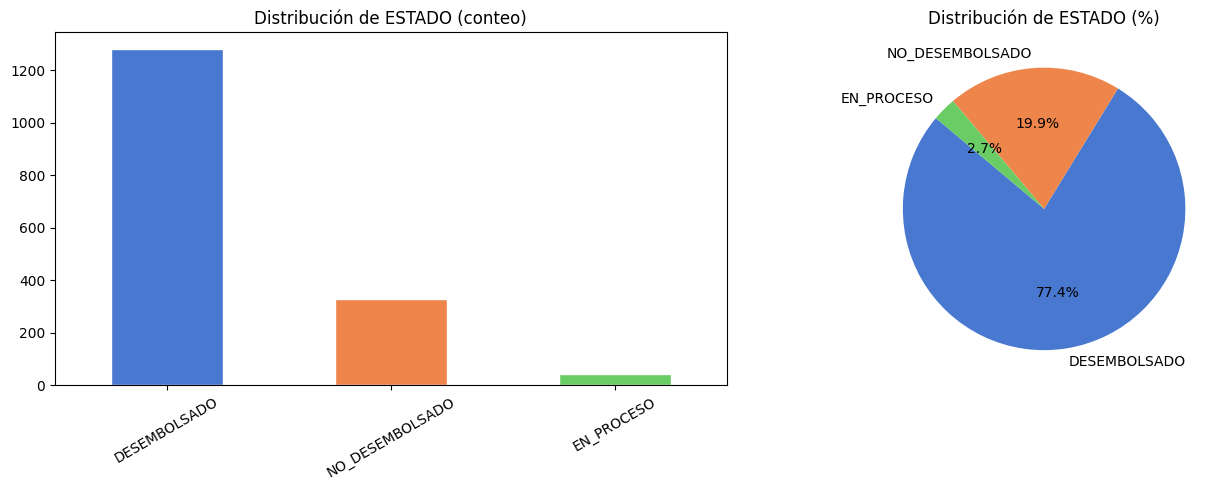

                 count  % del total
ESTADO                             
DESEMBOLSADO      1281        77.36
NO_DESEMBOLSADO    330        19.93
EN_PROCESO          45         2.72


In [251]:
conteo = df_clean["ESTADO"].value_counts()
pct = (conteo / len(df_clean) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
conteo.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted"), edgecolor="white")
axes[0].set_title("Distribución de ESTADO (conteo)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

axes[1].pie(pct, labels=pct.index, autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("muted"))
axes[1].set_title("Distribución de ESTADO (%)")
plt.tight_layout()
plt.show()
print(pd.concat([conteo, pct.rename("% del total")], axis=1))

La variable 'Estado' es una posible variable target para la problemática 1: podemos observar que hay un desbalance en las variables.

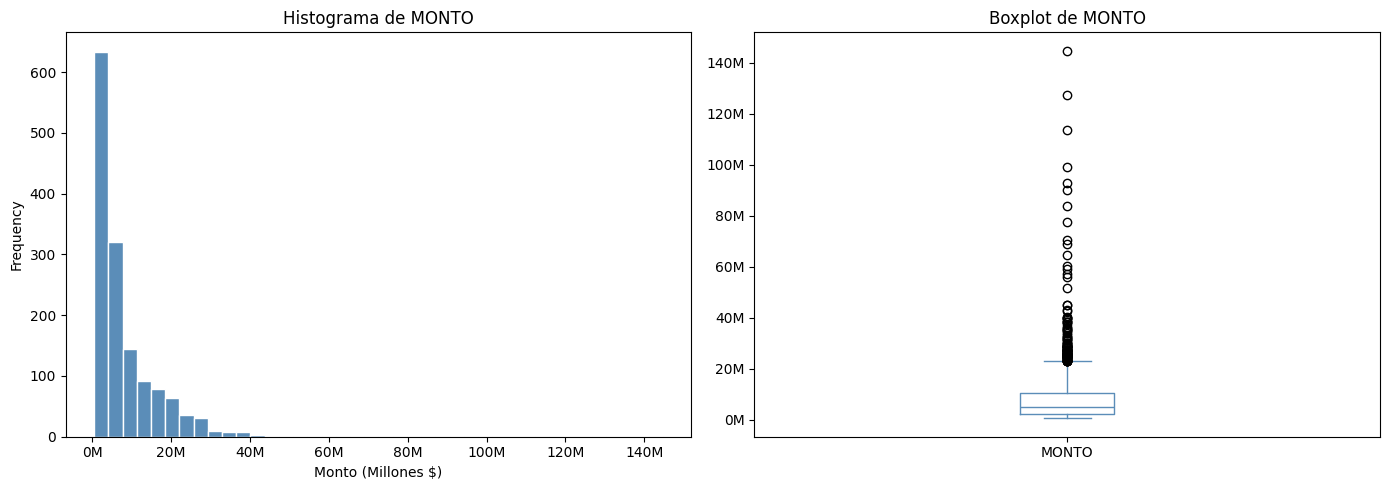

count      0.00
mean       8.64
std       11.36
min        0.50
25%        2.25
50%        5.00
75%       10.55
max      144.71
(valores en Millones $)


In [252]:
monto_m = df_clean["MONTO"].dropna() / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monto_m.plot(kind="hist", bins=40, ax=axes[0], color="#5B8DB8", edgecolor="white")
axes[0].set_title("Histograma de MONTO")
axes[0].set_xlabel("Monto (Millones $)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}M"))

monto_m.plot(kind="box", ax=axes[1], color="#5B8DB8")
axes[1].set_title("Boxplot de MONTO")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}M"))

plt.tight_layout()
plt.show()

desc = df_clean["MONTO"].describe() / 1_000_000
print(desc.round(2).to_string() + "\n(valores en Millones $)")

Se puede observar que la mayoría de los préstamos son hasta los 20M.
Sin embargo, se han realizado solicitudes de préstamos hasta los 140M.

/var/folders/mc/2gfzh5v563gcj4y_t_x5lrmc0000gn/T/ipykernel_2573/3334205755.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="ESTADO", y="MONTO_M", ax=axes[0], palette="muted")
/var/folders/mc/2gfzh5v563gcj4y_t_x5lrmc0000gn/T/ipykernel_2573/3334205755.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x="ESTADO", y="MONTO_M", ax=axes[1],


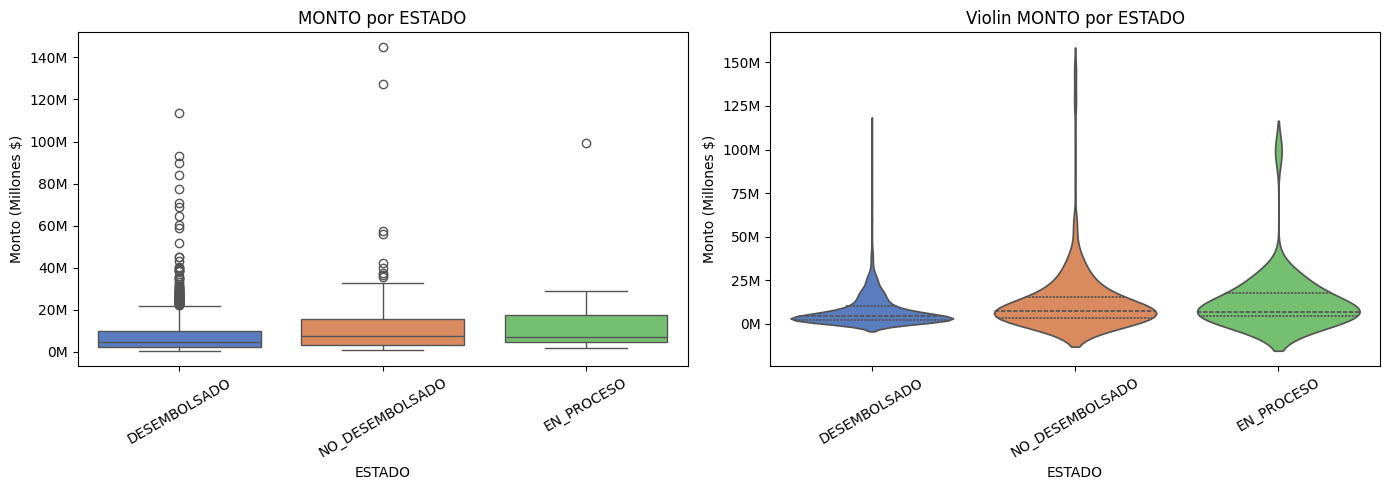

                  count   mean    std   min   25%   50%    75%     max
ESTADO                                                                
DESEMBOLSADO     1272.0   8.07   9.95  0.50  2.10  4.70  10.10  113.70
EN_PROCESO         33.0  13.07  17.39  1.90  4.82  7.00  17.66   99.21
NO_DESEMBOLSADO   139.0  12.83  18.51  0.75  3.40  7.53  15.55  144.71

(valores en Millones $)


In [253]:
df_clean["MONTO_M"] = df_clean["MONTO"] / 1_000_000
fmt_millones = plt.FuncFormatter(lambda x, _: f"{x:.0f}M")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x="ESTADO", y="MONTO_M", ax=axes[0], palette="muted")
axes[0].set_title("MONTO por ESTADO")
axes[0].set_ylabel("Monto (Millones $)")
axes[0].yaxis.set_major_formatter(fmt_millones)
axes[0].tick_params(axis="x", rotation=30)

sns.violinplot(data=df_clean, x="ESTADO", y="MONTO_M", ax=axes[1],
               palette="muted", inner="quartile")
axes[1].set_title("Violin MONTO por ESTADO")
axes[1].set_ylabel("Monto (Millones $)")
axes[1].yaxis.set_major_formatter(fmt_millones)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print((df_clean.groupby("ESTADO")["MONTO_M"].describe().round(2)).to_string())
print("\n(valores en Millones $)")

/var/folders/mc/2gfzh5v563gcj4y_t_x5lrmc0000gn/T/ipykernel_2573/1756475941.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="ESTADO", y="PLAZO", ax=axes[1], palette="muted")


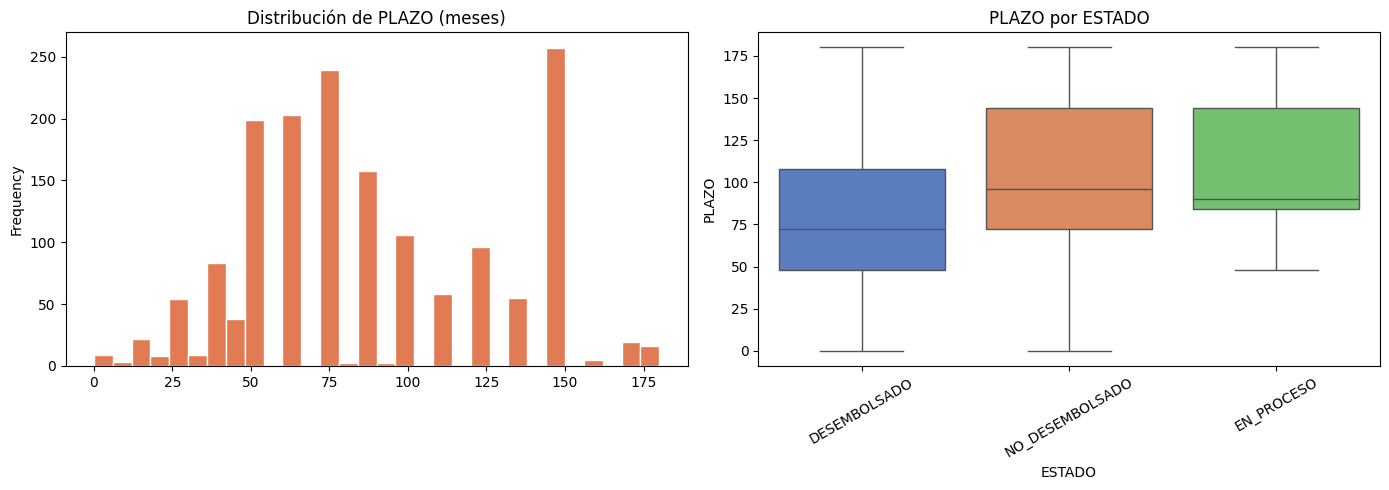

count    1644.00
mean       84.25
std        40.18
min         0.00
25%        48.00
50%        72.00
75%       120.00
max       180.00
Name: PLAZO, dtype: float64


In [254]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean["PLAZO"].dropna().plot(kind="hist", bins=30, ax=axes[0],
                                 color="#E07B54", edgecolor="white")
axes[0].set_title("Distribución de PLAZO (meses)")

sns.boxplot(data=df_clean, x="ESTADO", y="PLAZO", ax=axes[1], palette="muted")
axes[1].set_title("PLAZO por ESTADO")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
print(df_clean["PLAZO"].describe().round(2))

De media, los créditos desembolsados tiene un pazo de 75 meses, mientras que los no desembolsados, tienen un plazo ligeramente mayor de 100 meses.

/var/folders/mc/2gfzh5v563gcj4y_t_x5lrmc0000gn/T/ipykernel_2573/228212039.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="ESTADO", y="EDAD_AL_PRESTAMO",


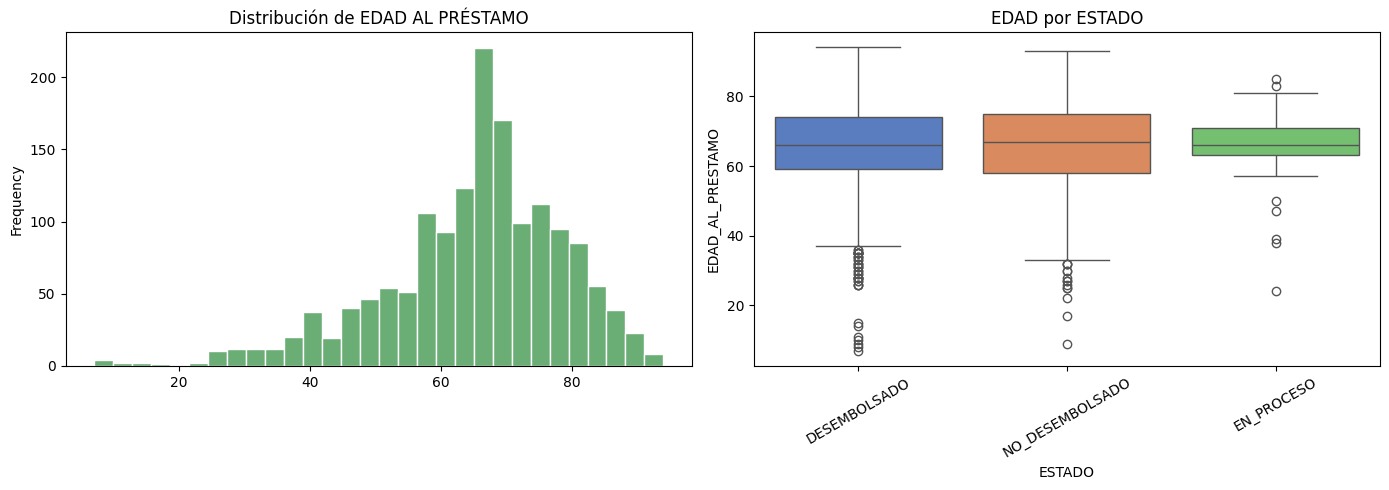

                  count   mean    std   min    25%   50%   75%   max
ESTADO                                                              
DESEMBOLSADO     1204.0  65.02  13.63   7.0   59.0  66.0  74.0  94.0
EN_PROCESO         42.0  65.33   12.0  24.0  63.25  66.0  71.0  85.0
NO_DESEMBOLSADO   306.0  64.76  14.68   9.0   58.0  67.0  75.0  93.0


In [255]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean["EDAD_AL_PRESTAMO"].dropna().plot(kind="hist", bins=30, ax=axes[0],
                                            color="#6BAE75", edgecolor="white")
axes[0].set_title("Distribución de EDAD AL PRÉSTAMO")

sns.boxplot(data=df_clean, x="ESTADO", y="EDAD_AL_PRESTAMO",
            ax=axes[1], palette="muted")
axes[1].set_title("EDAD por ESTADO")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
print(df_clean.groupby("ESTADO")["EDAD_AL_PRESTAMO"].describe().round(2))

Las distribuciones de edad son similares entre los estados, con una media de 65 años.

/var/folders/mc/2gfzh5v563gcj4y_t_x5lrmc0000gn/T/ipykernel_2573/573858958.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtrado, y=col, order=orden, ax=axes[0], palette="muted")


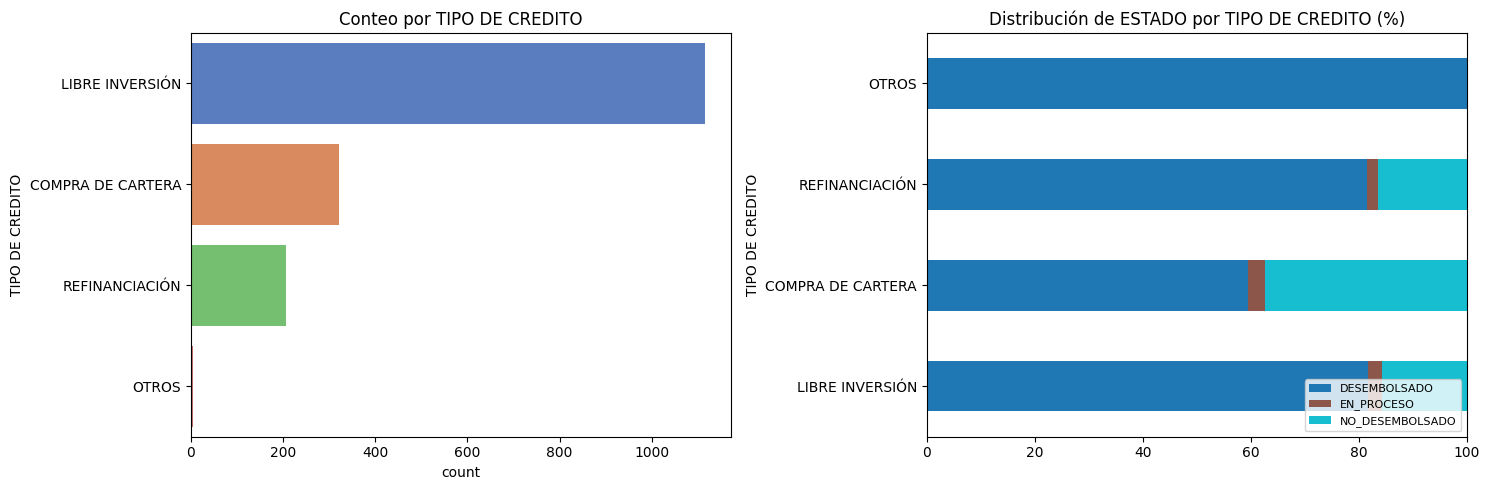

/var/folders/mc/2gfzh5v563gcj4y_t_x5lrmc0000gn/T/ipykernel_2573/573858958.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtrado, y=col, order=orden, ax=axes[0], palette="muted")


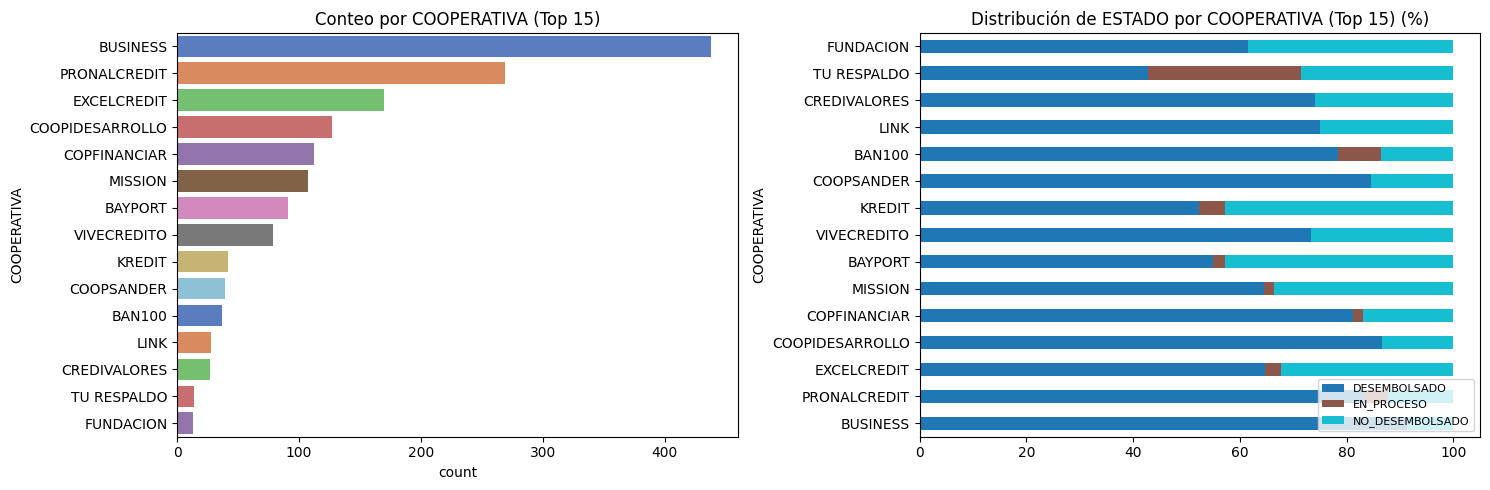

/var/folders/mc/2gfzh5v563gcj4y_t_x5lrmc0000gn/T/ipykernel_2573/573858958.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtrado, y=col, order=orden, ax=axes[0], palette="muted")


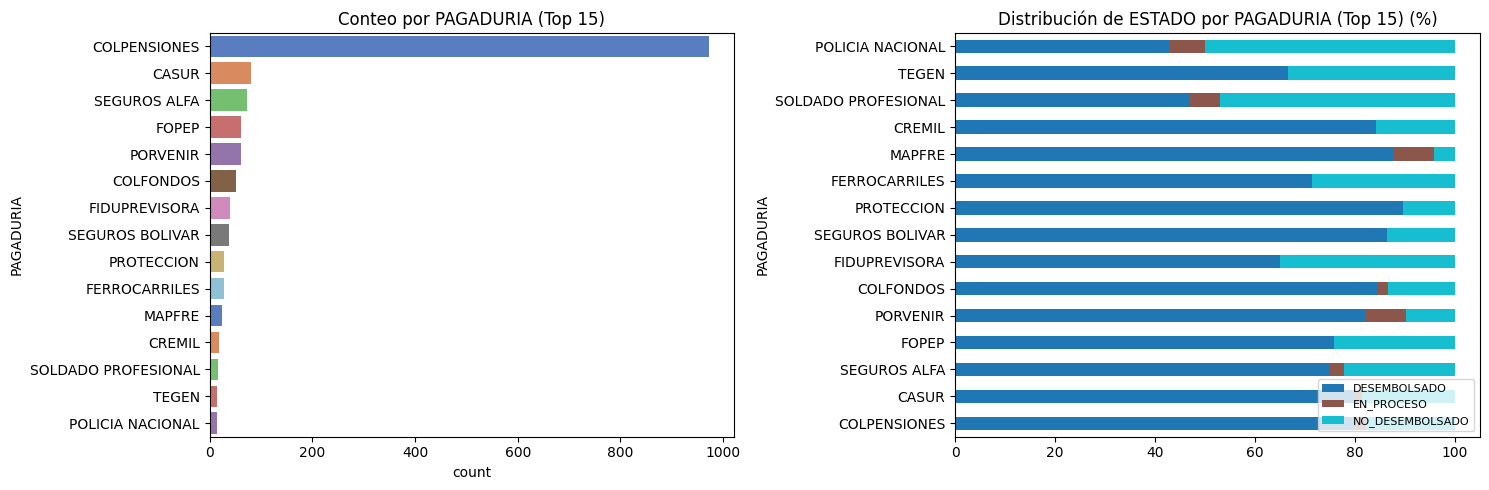

In [256]:
cols_cat = ["TIPO DE CREDITO", "COOPERATIVA", "PAGADURIA"]
TOP_N = 15

for col in cols_cat:
    # Top N categorías por volumen
    top_cats = df_clean[col].value_counts().nlargest(TOP_N).index
    df_filtrado = df_clean[df_clean[col].isin(top_cats)].copy()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    orden = df_filtrado[col].value_counts().index
    sns.countplot(data=df_filtrado, y=col, order=orden, ax=axes[0], palette="muted")
    titulo_extra = f" (Top {TOP_N})" if df_clean[col].nunique() > TOP_N else ""
    axes[0].set_title(f"Conteo por {col}{titulo_extra}")

    tasa = (df_filtrado.groupby([col, "ESTADO"])
                       .size()
                       .unstack(fill_value=0))
    tasa_pct = tasa.div(tasa.sum(axis=1), axis=0) * 100
    tasa_pct.loc[orden].plot(kind="barh", stacked=True, ax=axes[1], colormap="tab10")
    axes[1].set_title(f"Distribución de ESTADO por {col}{titulo_extra} (%)")
    axes[1].legend(loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()


- La mayoría de los créditos son de libre inversión.
- Las cooperativas por dónde más créditos se envía es Business, PronalCredit y ExcelCredit.
- En su mayoría, los pensionados pertenencen a la pagaduría Colpensiones.

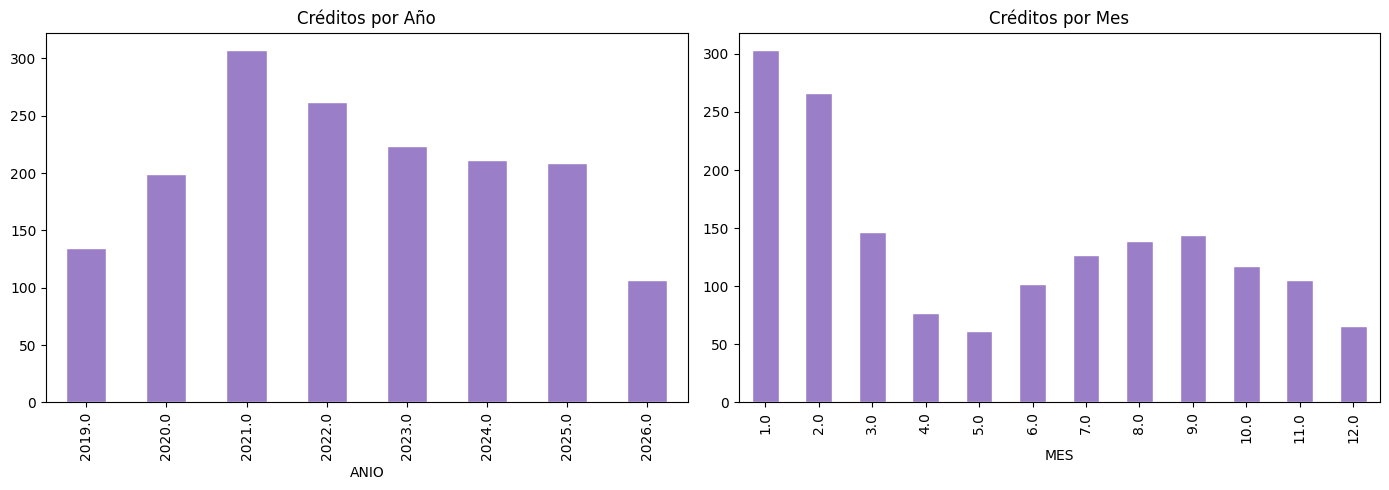

In [257]:
df_clean["ANIO"] = df_clean["FECHA"].dt.year
df_clean["MES"] = df_clean["FECHA"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean.groupby("ANIO").size().plot(kind="bar", ax=axes[0],
                                      color="#9B7EC8", edgecolor="white")
axes[0].set_title("Créditos por Año")

df_clean.groupby("MES").size().plot(kind="bar", ax=axes[1],
                                     color="#9B7EC8", edgecolor="white")
axes[1].set_title("Créditos por Mes")

plt.tight_layout()
plt.show()

Los meses donde más solicitudes de créditos se realizan son los dos primeros meses del año.
2021 fue el año donde ser recibieron más solicitudes de créditos.

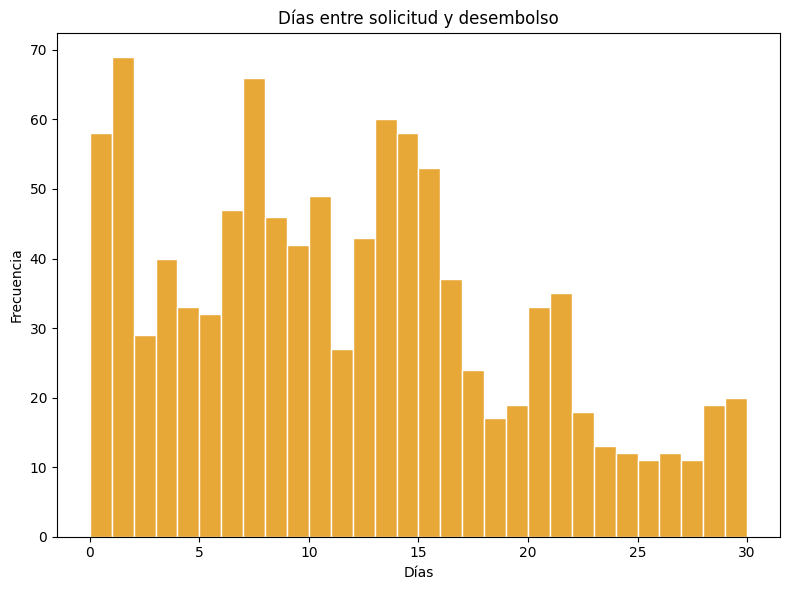

In [258]:
plt.figure(figsize=(8, 6))
df_clean["DIAS_HASTA_DESEMBOLSO"].dropna().plot(
    kind="hist", bins=30, color="#E8A838", edgecolor="white")
plt.title("Días entre solicitud y desembolso")
plt.xlabel("Días")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

La mayoría de créditos no tardan más de 15 días en desembolsarse.

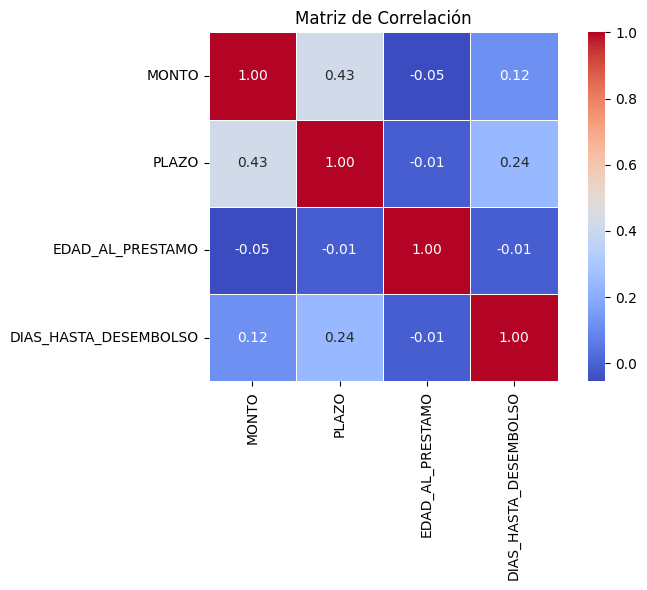

In [259]:
num_cols = ["MONTO", "PLAZO", "EDAD_AL_PRESTAMO", "DIAS_HASTA_DESEMBOLSO"]
corr = df_clean[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

Hay una correlación alta entre monto y plazo. Es decir, entre más alto el plazo, más alto el monto y viceversa.

EDA PROBLEMÁTICA 2

Análisis para determinar si las variables disponibles permiten predecir qué cooperativa es más adecuada para cada cliente.

In [260]:
# Distribución de COOPERATIVA (variable objetivo)
df_clean['COOPERATIVA'].value_counts()

COOPERATIVA
BUSINESS              438
PRONALCREDIT          269
EXCELCREDIT           170
COOPIDESARROLLO       127
COPFINANCIAR          112
MISSION               107
BAYPORT                91
VIVECREDITO            79
KREDIT                 42
COOPSANDER             39
BAN100                 37
LINK                   28
CREDIVALORES           27
TU RESPALDO            14
FUNDACION              13
KALA                   12
AVISTA                  9
GIROS Y FINANZAS        6
FIANTI                  6
ACTIVAR                 6
ACTIVOS Y FINANZAS      4
TEKA                    4
COMCREDIT               3
COBOLARQUI              2
SUDAMERIS               1
CREDIFINANCIERA         1
COMUNIDAD               1
Name: count, dtype: int64

In [261]:
# Distribución de COOPERATIVA en porcentaje
(df_clean['COOPERATIVA'].value_counts(normalize=True) * 100).round(2)

COOPERATIVA
BUSINESS              26.58
PRONALCREDIT          16.32
EXCELCREDIT           10.32
COOPIDESARROLLO        7.71
COPFINANCIAR           6.80
MISSION                6.49
BAYPORT                5.52
VIVECREDITO            4.79
KREDIT                 2.55
COOPSANDER             2.37
BAN100                 2.25
LINK                   1.70
CREDIVALORES           1.64
TU RESPALDO            0.85
FUNDACION              0.79
KALA                   0.73
AVISTA                 0.55
GIROS Y FINANZAS       0.36
FIANTI                 0.36
ACTIVAR                0.36
ACTIVOS Y FINANZAS     0.24
TEKA                   0.24
COMCREDIT              0.18
COBOLARQUI             0.12
SUDAMERIS              0.06
CREDIFINANCIERA        0.06
COMUNIDAD              0.06
Name: proportion, dtype: float64

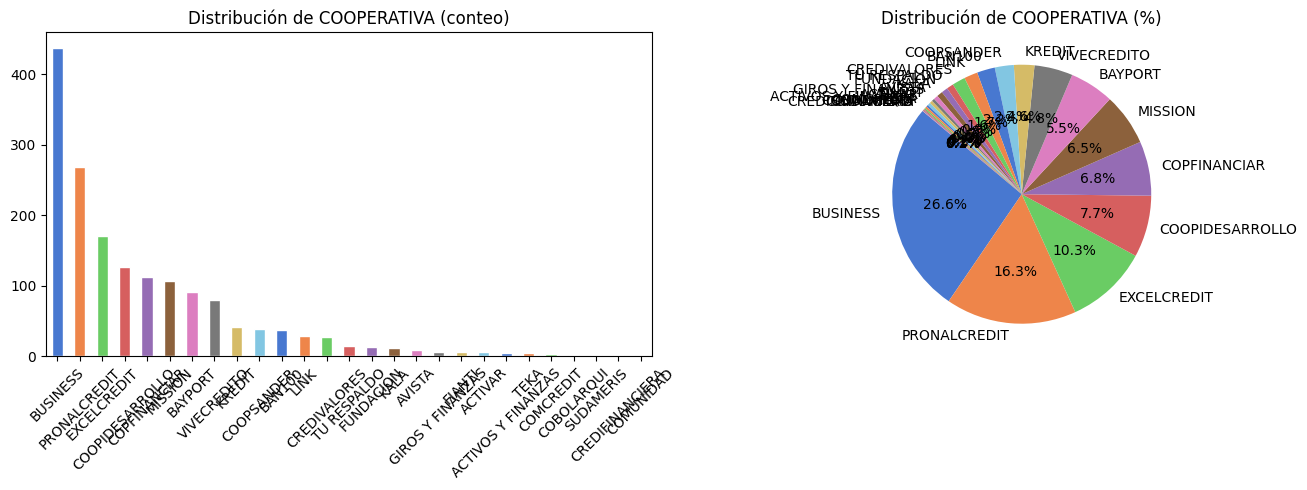

In [262]:
# Gráfica: Distribución de COOPERATIVA
conteo_coop = df_clean['COOPERATIVA'].value_counts()
pct_coop = (conteo_coop / len(df_clean) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conteo_coop.plot(kind='bar', ax=axes[0],
                  color=sns.color_palette('muted'), edgecolor='white')
axes[0].set_title('Distribución de COOPERATIVA (conteo)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(pct_coop, labels=pct_coop.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('muted'))
axes[1].set_title('Distribución de COOPERATIVA (%)')

plt.tight_layout()
plt.show()

Las cooperativas más frecuentes son BUSINESS, PRONALCREDIT y EXCELCREDIT, representando más del 50% de los créditos.

In [263]:
# Tasa de aprobación por cooperativa
tasa_aprobacion = (
    df_clean.groupby('COOPERATIVA')['ESTADO']
    .apply(lambda x: (x == 'DESEMBOLSADO').sum() / len(x) * 100)
    .round(2)
    .sort_values(ascending=False)
)
tasa_aprobacion

COOPERATIVA
BUSINESS              91.10
COOPIDESARROLLO       86.61
COOPSANDER            84.62
FIANTI                83.33
PRONALCREDIT          83.27
COPFINANCIAR          81.25
BAN100                78.38
AVISTA                77.78
TEKA                  75.00
LINK                  75.00
CREDIVALORES          74.07
VIVECREDITO           73.42
COMCREDIT             66.67
ACTIVAR               66.67
EXCELCREDIT           64.71
MISSION               64.49
FUNDACION             61.54
BAYPORT               54.95
KREDIT                52.38
GIROS Y FINANZAS      50.00
COBOLARQUI            50.00
TU RESPALDO           42.86
KALA                  41.67
ACTIVOS Y FINANZAS    25.00
CREDIFINANCIERA        0.00
COMUNIDAD              0.00
SUDAMERIS              0.00
Name: ESTADO, dtype: float64

Algunas cooperativas tienen tasas de aprobación muy altas (100%) mientras otras tienen negaciones. Esto indica que hay factores que determinan qué cooperativa es viable para cada cliente.

In [264]:
# Tratamiento de outliers en EDAD_AL_PRESTAMO (método IQR)
Q1 = df_clean['EDAD_AL_PRESTAMO'].quantile(0.25)
Q3 = df_clean['EDAD_AL_PRESTAMO'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

mask_outlier = (
    (df_clean['EDAD_AL_PRESTAMO'] < limite_inf) |
    (df_clean['EDAD_AL_PRESTAMO'] > limite_sup)
)
outliers_edad = df_clean.loc[mask_outlier, 'EDAD_AL_PRESTAMO']

print(f'Límite inferior (Q1 - 1.5·IQR): {limite_inf:.1f} años')
print(f'Límite superior (Q3 + 1.5·IQR): {limite_sup:.1f} años')
print(f'Outliers detectados: {len(outliers_edad)} registros')
print(f'\nValores outlier:')
print(outliers_edad.sort_values().to_string())

# Reemplazar outliers por NaN
df_clean.loc[mask_outlier, 'EDAD_AL_PRESTAMO'] = float('nan')

print(f'\nEdad mínima tras tratamiento: {df_clean["EDAD_AL_PRESTAMO"].min():.0f} años')
print(f'Edad máxima tras tratamiento: {df_clean["EDAD_AL_PRESTAMO"].max():.0f} años')
print(f'Nulos en EDAD_AL_PRESTAMO tras tratamiento: {df_clean["EDAD_AL_PRESTAMO"].isna().sum()}')

Límite inferior (Q1 - 1.5·IQR): 36.5 años
Límite superior (Q3 + 1.5·IQR): 96.5 años
Outliers detectados: 62 registros

Valores outlier:
72       7.0
273      8.0
982      9.0
387      9.0
561     10.0
974     11.0
1019    14.0
858     15.0
154     17.0
14      22.0
518     24.0
677     25.0
1629    25.0
1500    26.0
378     26.0
211     26.0
529     26.0
27      27.0
742     27.0
28      27.0
577     27.0
105     28.0
575     28.0
111     28.0
19      28.0
496     28.0
194     28.0
217     29.0
1235    29.0
470     30.0
108     30.0
213     30.0
636     30.0
1120    31.0
755     31.0
316     31.0
422     32.0
1247    32.0
589     32.0
574     32.0
551     32.0
784     32.0
881     33.0
460     33.0
524     33.0
952     34.0
1001    34.0
407     34.0
788     35.0
1245    35.0
1230    35.0
1225    35.0
1156    35.0
1171    35.0
983     35.0
484     35.0
494     35.0
776     36.0
1459    36.0
212     36.0
1214    36.0
1518    36.0

Edad mínima tras tratamiento: 37 años
Edad máxima tras tr

In [265]:
# Edad promedio por cooperativa
df_clean.groupby('COOPERATIVA')['EDAD_AL_PRESTAMO'].agg(['mean', 'min', 'max']).round(1)

,mean,min,max
COOPERATIVA,,,
ACTIVAR,66.5,49.0,77.0
ACTIVOS Y FINANZAS,63.0,41.0,76.0
AVISTA,74.4,59.0,83.0
BAN100,67.6,37.0,84.0
BAYPORT,64.5,37.0,79.0
BUSINESS,65.3,37.0,83.0
COBOLARQUI,88.0,85.0,91.0
COMCREDIT,67.0,59.0,79.0
COMUNIDAD,91.0,91.0,91.0


/var/folders/mc/2gfzh5v563gcj4y_t_x5lrmc0000gn/T/ipykernel_2573/2986868804.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, y='COOPERATIVA', x='EDAD_AL_PRESTAMO',


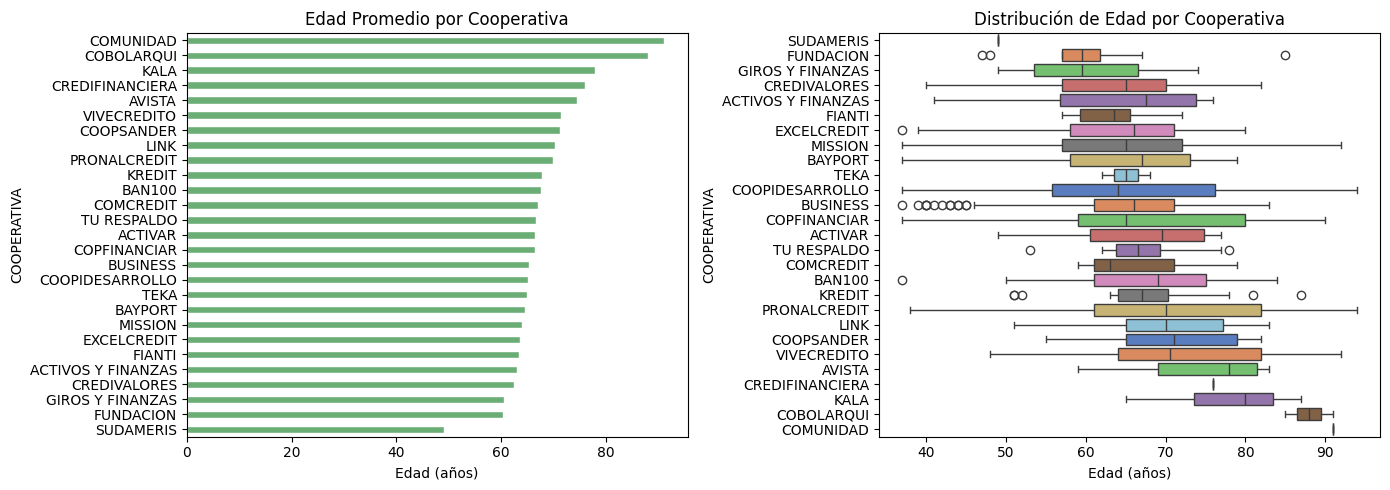

In [266]:
# Gráfica: Edad por cooperativa
edad_media = df_clean.groupby('COOPERATIVA')['EDAD_AL_PRESTAMO'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edad_media.plot(kind='barh', ax=axes[0], color='#6BAE75', edgecolor='white')
axes[0].set_title('Edad Promedio por Cooperativa')
axes[0].set_xlabel('Edad (años)')

sns.boxplot(data=df_clean, y='COOPERATIVA', x='EDAD_AL_PRESTAMO',
            ax=axes[1], palette='muted', order=edad_media.index)
axes[1].set_title('Distribución de Edad por Cooperativa')
axes[1].set_xlabel('Edad (años)')

plt.tight_layout()
plt.show()

Las cooperativas atienden perfiles de edad muy diferentes. BUSINESS tiene clientes más jóvenes (media 53) mientras otras como COPFINANCIAR atienden clientes de mayor edad (media 71). Esto sugiere que la edad es un factor diferenciador importante.

In [267]:
# Monto promedio por cooperativa
df_clean.groupby('COOPERATIVA')['MONTO'].mean().round(0).sort_values(ascending=False)

COOPERATIVA
KREDIT                28164485.0
TU RESPALDO           26084448.0
ACTIVOS Y FINANZAS    23856500.0
FIANTI                22956693.0
GIROS Y FINANZAS      19375000.0
BAN100                17409387.0
BAYPORT               16770470.0
VIVECREDITO           14643662.0
EXCELCREDIT           13794977.0
CREDIVALORES          12932547.0
TEKA                  12731545.0
CREDIFINANCIERA       10676000.0
LINK                  10104810.0
COMCREDIT             10067885.0
SUDAMERIS              9500000.0
MISSION                8173043.0
COMUNIDAD              8000000.0
AVISTA                 7726108.0
COOPSANDER             7023333.0
COPFINANCIAR           6547249.0
ACTIVAR                6200318.0
BUSINESS               5438372.0
PRONALCREDIT           5222626.0
COOPIDESARROLLO        4877924.0
COBOLARQUI             4750000.0
KALA                   4450035.0
FUNDACION              2975000.0
Name: MONTO, dtype: float64

/var/folders/mc/2gfzh5v563gcj4y_t_x5lrmc0000gn/T/ipykernel_2573/2703928485.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_aux, y='COOPERATIVA', x='MONTO_M',


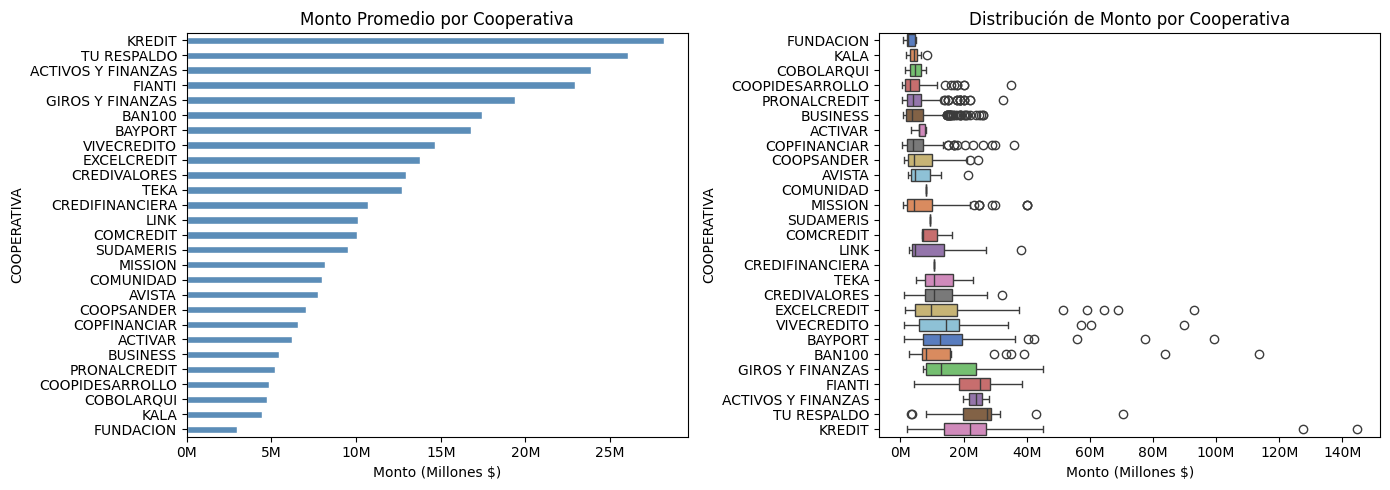

In [268]:
# Gráfica: Monto por cooperativa
fmt_m = plt.FuncFormatter(lambda x, _: f'{x:.0f}M')
monto_medio = df_clean.groupby('COOPERATIVA')['MONTO'].mean().sort_values() / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monto_medio.plot(kind='barh', ax=axes[0], color='#5B8DB8', edgecolor='white')
axes[0].set_title('Monto Promedio por Cooperativa')
axes[0].xaxis.set_major_formatter(fmt_m)
axes[0].set_xlabel('Monto (Millones $)')

df_aux = df_clean.copy()
df_aux['MONTO_M'] = df_aux['MONTO'] / 1_000_000
sns.boxplot(data=df_aux, y='COOPERATIVA', x='MONTO_M',
            ax=axes[1], palette='muted', order=monto_medio.index)
axes[1].set_title('Distribución de Monto por Cooperativa')
axes[1].xaxis.set_major_formatter(fmt_m)
axes[1].set_xlabel('Monto (Millones $)')

plt.tight_layout()
plt.show()

Hay diferencias significativas en los montos promedios por cooperativa, desde 5.5M hasta más de 21M. Esto indica que el monto es un factor para seleccionar la cooperativa.

In [269]:
# Plazo promedio por cooperativa
df_clean.groupby('COOPERATIVA')['PLAZO'].mean().round(1).sort_values(ascending=False)

COOPERATIVA
TU RESPALDO           162.0
ACTIVOS Y FINANZAS    162.0
KREDIT                150.0
COMCREDIT             140.0
LINK                  135.5
VIVECREDITO           133.9
CREDIVALORES          131.6
KALA                  126.5
BAYPORT               124.6
AVISTA                121.3
FIANTI                120.0
BAN100                120.0
CREDIFINANCIERA       120.0
EXCELCREDIT           117.4
GIROS Y FINANZAS      116.0
ACTIVAR               112.0
SUDAMERIS              96.0
MISSION                84.8
TEKA                   72.0
COPFINANCIAR           68.0
PRONALCREDIT           67.0
COOPSANDER             60.9
COMUNIDAD              60.0
COOPIDESARROLLO        59.9
BUSINESS               57.9
COBOLARQUI             42.0
FUNDACION              25.8
Name: PLAZO, dtype: float64

/var/folders/mc/2gfzh5v563gcj4y_t_x5lrmc0000gn/T/ipykernel_2573/151218475.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, y='COOPERATIVA', x='PLAZO',


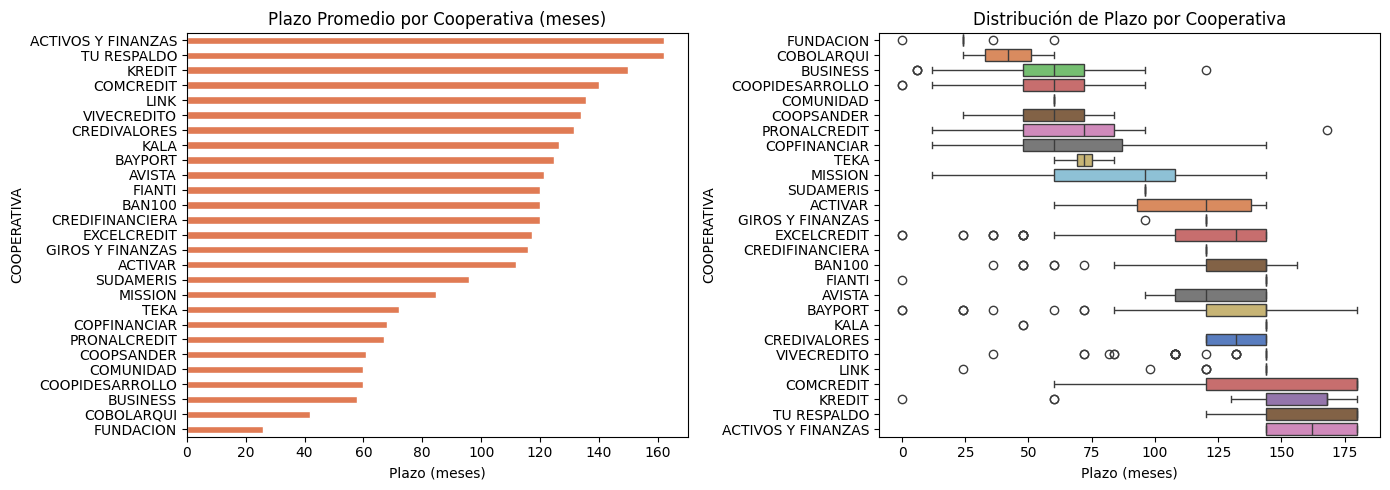

In [270]:
# Gráfica: Plazo por cooperativa
plazo_medio = df_clean.groupby('COOPERATIVA')['PLAZO'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plazo_medio.plot(kind='barh', ax=axes[0], color='#E07B54', edgecolor='white')
axes[0].set_title('Plazo Promedio por Cooperativa (meses)')
axes[0].set_xlabel('Plazo (meses)')

sns.boxplot(data=df_clean, y='COOPERATIVA', x='PLAZO',
            ax=axes[1], palette='muted', order=plazo_medio.index)
axes[1].set_title('Distribución de Plazo por Cooperativa')
axes[1].set_xlabel('Plazo (meses)')

plt.tight_layout()
plt.show()

Las cooperativas con plazos más altos tienden a manejar montos mayores, consistente con la correlación observada entre MONTO y PLAZO.

In [271]:
# Distribución de cooperativas por tipo de crédito
pd.crosstab(df_clean['TIPO DE CREDITO'], df_clean['COOPERATIVA'])

COOPERATIVA,ACTIVAR,ACTIVOS Y FINANZAS,AVISTA,BAN100,BAYPORT,BUSINESS,COBOLARQUI,COMCREDIT,COMUNIDAD,COOPIDESARROLLO,...,GIROS Y FINANZAS,KALA,KREDIT,LINK,MISSION,PRONALCREDIT,SUDAMERIS,TEKA,TU RESPALDO,VIVECREDITO
TIPO DE CREDITO,,,,,,,,,,,,,,,,,,,,,
COMPRA DE CARTERA,0,3,3,8,48,15,0,2,0,3,...,5,2,37,14,29,10,1,0,11,47
LIBRE INVERSIÓN,6,1,5,24,32,340,2,1,1,94,...,1,9,4,14,67,237,0,3,3,32
OTROS,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
REFINANCIACIÓN,0,0,1,5,11,77,0,0,0,29,...,0,0,1,0,11,21,0,1,0,0


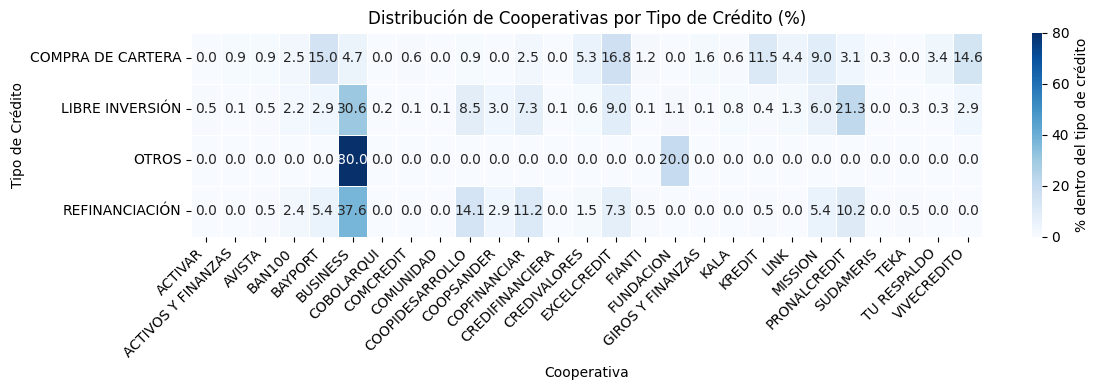

In [272]:
# Gráfica: Distribución de cooperativas por tipo de crédito (heatmap)
ct_tipo = pd.crosstab(df_clean['TIPO DE CREDITO'], df_clean['COOPERATIVA'],
                       normalize='index') * 100

plt.figure(figsize=(12, 4))
sns.heatmap(ct_tipo, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': '% dentro del tipo de crédito'})
plt.title('Distribución de Cooperativas por Tipo de Crédito (%)')
plt.xlabel('Cooperativa')
plt.ylabel('Tipo de Crédito')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cada tipo de crédito tiene afinidad por ciertas cooperativas. Por ejemplo, REFINANCIACION se concentra en PRONALCREDIT, mientras que COMPRA está más distribuida.

In [273]:
# Distribución de cooperativas por pagaduría
pd.crosstab(df_clean['PAGADURIA'], df_clean['COOPERATIVA'])

COOPERATIVA,ACTIVAR,ACTIVOS Y FINANZAS,AVISTA,BAN100,BAYPORT,BUSINESS,COBOLARQUI,COMCREDIT,COMUNIDAD,COOPIDESARROLLO,...,GIROS Y FINANZAS,KALA,KREDIT,LINK,MISSION,PRONALCREDIT,SUDAMERIS,TEKA,TU RESPALDO,VIVECREDITO
PAGADURIA,,,,,,,,,,,,,,,,,,,,,
ACTIVO,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ALLIANZ SEGUROS,0,0,0,0,0,0,0,0,0,10,...,0,0,0,0,0,0,0,0,0,0
ASULADO,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,3,0,0,0,0
AXA COLPATRIA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,4,0,0,0,0
BBVA SEGUROS,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CAGEN,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
CASUR,0,0,1,0,7,8,0,0,0,28,...,0,0,3,0,5,6,0,0,0,5
COLFONDOS,0,0,0,1,0,26,0,0,0,13,...,1,0,2,0,0,4,0,0,1,0
COLPENSIONES,1,2,5,30,44,289,1,3,0,42,...,4,11,33,26,61,167,0,2,9,59


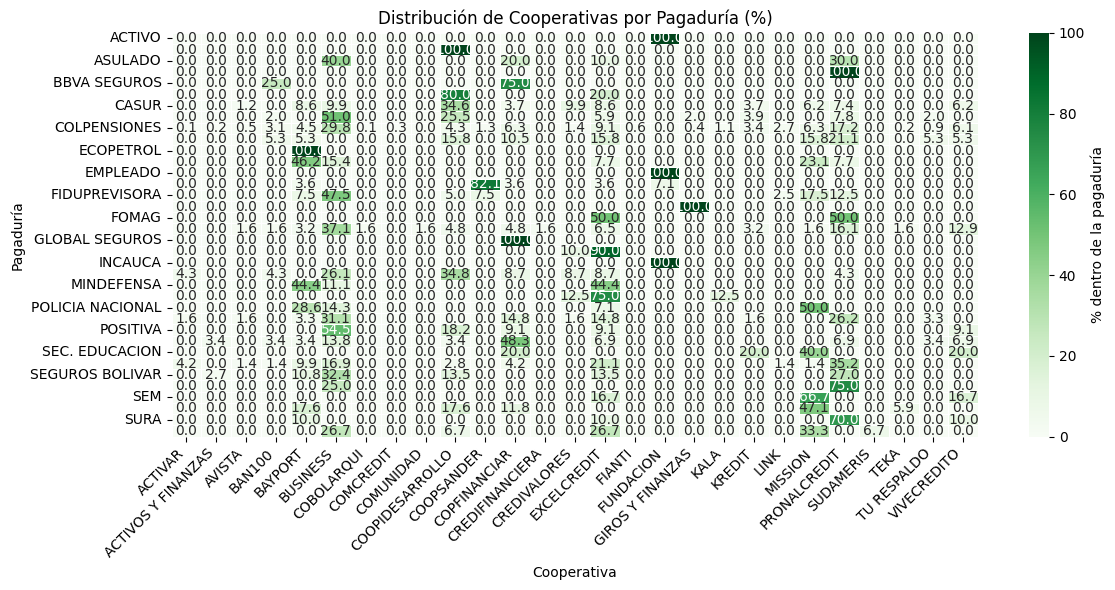

In [274]:
# Gráfica: Distribución de cooperativas por pagaduría (heatmap)
ct_pag = pd.crosstab(df_clean['PAGADURIA'], df_clean['COOPERATIVA'],
                      normalize='index') * 100

plt.figure(figsize=(12, 6))
sns.heatmap(ct_pag, annot=True, fmt='.1f', cmap='Greens',
            linewidths=0.5, cbar_kws={'label': '% dentro de la pagaduría'})
plt.title('Distribución de Cooperativas por Pagaduría (%)')
plt.xlabel('Cooperativa')
plt.ylabel('Pagaduría')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cada pagaduría tiene preferencia por ciertas cooperativas. Esto es clave porque cada cooperativa puede tener restricciones según la pagaduría del cliente.

In [275]:
# Conclusión sobre viabilidad para Problemática 2
print('=' * 60)
print('CONCLUSIONES: Viabilidad del modelo para Problemática 2')
print('=' * 60)
print()
print('VARIABLES DISPONIBLES:')
print('- EDAD_AL_PRESTAMO: Factor diferenciador (edades varían por cooperativa)')
print('- TIPO DE CREDITO: Afinidad con cooperativas específicas')
print('- PAGADURIA: Restricciones por entidad pagadora')
print('- MONTO: Diferencias significativas entre cooperativas')
print('- PLAZO: Perfiles de plazos diferentes por cooperativa')
print()
print('CONCLUSION:')
print('Las variables disponibles SÍ permiten construir un modelo predictivo')
print('para recomendar la cooperativa más adecuada. Las diferencias en')
print('perfiles de edad, montos, plazos y la relación con pagadurías')
print('sugieren que existe patrón identificable para predecir la cooperativa.')
print()
print('LIMITACIONES:')
print('- No tenemos información directa sobre reglas de cada cooperativa')
print('- Variables como RAR (tasa), comisiones no están disponibles')
print('- Se asume que la cooperativa elegida fue la correcta para créditos aprobados')

CONCLUSIONES: Viabilidad del modelo para Problemática 2

VARIABLES DISPONIBLES:
- EDAD_AL_PRESTAMO: Factor diferenciador (edades varían por cooperativa)
- TIPO DE CREDITO: Afinidad con cooperativas específicas
- PAGADURIA: Restricciones por entidad pagadora
- MONTO: Diferencias significativas entre cooperativas
- PLAZO: Perfiles de plazos diferentes por cooperativa

CONCLUSION:
Las variables disponibles SÍ permiten construir un modelo predictivo
para recomendar la cooperativa más adecuada. Las diferencias en
perfiles de edad, montos, plazos y la relación con pagadurías
sugieren que existe patrón identificable para predecir la cooperativa.

LIMITACIONES:
- No tenemos información directa sobre reglas de cada cooperativa
- Variables como RAR (tasa), comisiones no están disponibles
- Se asume que la cooperativa elegida fue la correcta para créditos aprobados


In [276]:
# Guardar dataset limpio y crear un enlace de descarga
output_path = '../data/dataset_limpio.csv'
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'Dataset limpio guardado en: {output_path}')

from IPython.display import FileLink, display
display(FileLink(output_path, result_html_prefix='Descarga: '))

Dataset limpio guardado en: ../data/dataset_limpio.csv


/Users/estefania/Documents/proyecto IA Apoyo Crediticio/data/dataset_limpio.csv